# Análise dos dados brutos

## Objetivos:
- Analisar os dados obtidos no notebook bronze_bruta onde os dados brutos foram organizados e padronizados.

Podemos observar então os primeiros resultados e outros dados gerais das amostras da tabelona que obtemos na construção dessa camada bronze:

In [3]:
import pandas as pd

FILE_PATH = "../data/bronze/full_table.parquet"

df = pd.read_parquet(FILE_PATH)

print("\n" + "="*60)
print("VISÃO GERAL DO DATASET")
print("="*60)

print(f"\nShape (linhas, colunas): {df.shape}")
print(f"Total de colunas: {len(df.columns)}")

# =========================
# COLUNAS ORGANIZADAS
# =========================
print("\n" + "="*60)
print("COLUNAS DO DATASET")
print("="*60)

for i, col in enumerate(df.columns):
    print(f"{i:02d} | {col}")

# =========================
# HEAD FORMATADO
# =========================
print("\n" + "="*60)
print("PRIMEIRAS LINHAS (HEAD)")
print("="*60)

print(df.head().to_string())

# =========================
# AMOSTRA ALEATÓRIA
# =========================
print("\n" + "="*60)
print("AMOSTRA ALEATÓRIA")
print("="*60)

print(df.sample(5).to_string())

# =========================
# TIPOS DE DADOS
# =========================
print("\n" + "="*60)
print("TIPOS DE DADOS")
print("="*60)

print(df.dtypes)

# =========================
# VALORES NULOS
# =========================
print("\n" + "="*60)
print("VALORES NULOS (TOP 20)")
print("="*60)

print(df.isna().sum().sort_values(ascending=False).head(20))

# =========================
# CHECAGEM DE PADRÃO
# =========================
print("\n" + "="*60)
print("VALIDAÇÃO RÁPIDA")
print("="*60)

print("Timestamp é string:", df["timestamp"].dtype)
print("Patient_id é string:", df["patient_id"].dtype)
print("Session tem valores nulos:", df["session"].isna().sum())
print("Label dtype:", df["label"].dtype)


VISÃO GERAL DO DATASET

Shape (linhas, colunas): (3872933, 63)
Total de colunas: 63

COLUNAS DO DATASET
00 | timestamp
01 | patient_id
02 | task_id
03 | session
04 | EEG-FP1
05 | EEG-FP2
06 | EEG-F3
07 | EEG-F4
08 | EEG-C3
09 | EEG-C4
10 | EEG-P3
11 | EEG-P4
12 | EEG-O1
13 | EEG-O2
14 | EEG-F7
15 | EEG-F8
16 | EEG-P7
17 | EEG-P8
18 | EEG-FZ
19 | EEG-CZ
20 | EEG-PZ
21 | EEG-FC1
22 | EEG-FC2
23 | EEG-CP1
24 | EEG-CP2
25 | EEG-FC5
26 | EEG-FC6
27 | EEG-CP5
28 | EEG-CP6
29 | EMG-RTA
30 | EMG-LTA
31 | EMG-RGS
32 | IO
33 | ECG
34 | LShank-ACCX
35 | LShank-ACCY
36 | LShank-ACCZ
37 | LShank-GYRO-X
38 | LShank-GYRO-Y
39 | LShank-GYRO-Z
40 | LShank-NC/SC
41 | RShank-ACCX
42 | RShank-ACCY
43 | RShank-ACCZ
44 | RShank-GYRO-X
45 | RShank-GYRO-Y
46 | RShank-GYRO-Z
47 | RShank-NC/SC
48 | Waist-ACCX
49 | Waist-ACCY
50 | Waist-ACCZ
51 | Waist-GYRO-X
52 | Waist-GYRO-Y
53 | Waist-GYRO-Z
54 | Waist-NC/SC
55 | Arm-ACCX
56 | Arm-ACCY
57 | Arm-ACCZ
58 | Arm-GYRO-X
59 | Arm-GYRO-Y
60 | Arm-GYRO-Z
61 | Arm-NC

Temos um total de 3504894 linhas e 63 colunas somando as medições de todos os pacientes, por conta da padronização, é de se esperar que muitos pacientes tenham valores faltantes de medidas.

# Análise Estrutural do Dataset Bruto

## Visão Geral

Nosso dataset consolidado apresenta as seguintes características:

- **Total de linhas:** ~3.5 milhões  
- **Total de colunas:** 63  
- **Tipos de dados predominantes:** `float32` (biosinais) e `string` (metadados)

A estrutura foi organizada de forma tabular, onde:

- Cada linha representa um instante temporal (`timestamp`)
- Cada coluna representa um canal de sinal ou metadado

---

## Estrutura dos Dados

O dataset é composto por múltiplas fontes de sinais:

### EEG (Eletroencefalograma)
Canais como:
- `EEG-FP1`, `EEG-FP2`, `EEG-F3`, `EEG-F4`
- `EEG-C3`, `EEG-C4`, `EEG-P3`, `EEG-P4`
- `EEG-O1`, `EEG-O2`, etc.

Esses sinais representam a atividade elétrica cerebral ao longo do tempo.

---

### EMG / ECG / IO
- `EMG-RTA`, `EMG-LTA`, `EMG-RGS`
- `ECG`
- `IO`

Esses canais complementam o EEG com informações musculares e cardíacas.

---

### Sensores Inerciais (IMU)

Cada sensor possui 7 canais:

- Acelerômetro: `ACCX`, `ACCY`, `ACCZ`
- Giroscópio: `GYRO-X`, `GYRO-Y`, `GYRO-Z`
- Canal adicional: `NC/SC`

Sensores disponíveis:

- `LShank` (perna esquerda)
- `RShank` (perna direita)
- `Waist` (cintura)
- `Arm` (braço)

---

## Heterogeneidade dos Dados

Nosso dataset é **multimodal e heterogêneo**, o que implica:

- Nem todos os pacientes possuem todos os sensores  
- Nem todos os canais estão presentes em todos os registros  
- Isso resulta em **valores ausentes (NaN)**

Essa característica é comum em datasets médicos reais e não representa erro.

---

## Valores Ausentes (NaNs)

A presença de valores nulos ocorre principalmente por:

### Sensores não disponíveis
Exemplo:
- Um paciente pode ter `RShank` mas não `Waist`
- As colunas ausentes são preenchidas com `NaN`

---

### Canais não presentes no dataset

Alguns canais esperados em montagens EEG clássicas, como:

- `EEG-FZ`
- `EEG-CZ`
- `EEG-PZ`

não fazem parte do dataset original.  

Essas colunas aparecem totalmente preenchidas com `NaN`, o que indica que:

> Esses sinais não foram coletados durante o experimento.

---

### Biosinais parciais

Canais como `ECG`, `IO` e alguns `EMG` aparecem apenas em parte dos pacientes, resultando em grande quantidade de valores ausentes.

---

## Labels e Task ID

### Label

A coluna `label` encontra-se **totalmente vazia (NaN)** neste dataset.

Isso ocorre porque:

- A rotulação é uma tarefa custosa e especializada  
- Os responsáveis pelo dataset já realizaram esse processo previamente  

Os labels estão disponíveis em:

- Forma bruta: `data/raw/filtered.txt`  
- Forma estruturada: `data/bronze/filtered_parquet`  

Portanto:

> Este dataset representa os dados **em estado bruto (raw)**, ainda sem anotação.

---

### Task ID

A coluna `task_id` aparece como:

```unknown```

Isso é esperado, pois:

Os dados ainda não foram associados às tarefas experimentais
A divisão por tarefas já está presente no dataset filtrado

Assim:

O task_id será corretamente preenchido ao integrar os dados com o dataset filtrado (filtered_parquet)

## Metadados

### patient_id

Identifica o paciente ao qual cada amostra pertence.

Exemplo:

001, 002, ..., 011

### session

- Representa a sessão de coleta do paciente.

- Para a maioria dos pacientes:

- session = 1

- Para casos específicos, como o patient_id = 008:

session = 1 ou 2


### timestamp

- Representa o tempo da amostra
- Está em formato string
- Derivado da frequência de amostragem do sinal

Cada linha corresponde a um instante contínuo no tempo.

## Padronização do Dataset

Nosso dataset foi estruturado para garantir:

- Mesmo número de colunas para todos os registros
- Organização consistente entre pacientes
- Compatibilidade com pipelines de Machine Learning

Isso implica que:

- Colunas ausentes são mantidas e preenchidas com NaN
- O schema permanece fixo, mesmo com variações entre sujeitos

## Interpretação Geral

Este dataset representa um cenário realista de dados biomédicos:

- Alta dimensionalidade
- Multiplas fontes de sinal
- Presença significativa de dados ausentes
- Separação entre dados brutos e dados filtrados

A estrutura atual permite:

- Análises exploratórias robustas
- Integração futura com labels
- Preparação para modelos de aprendizado de máquina


# Estatísticas e Gráficos do Dataset Bruto
## 1. Estatísticas Descritivas 

In [4]:
print("="*60)
print("ESTATÍSTICAS DESCRITIVAS")
print("="*60)

desc = df.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print(desc.T)

ESTATÍSTICAS DESCRITIVAS
                   count          mean          std           min  \
EEG-FP1        3872933.0  2.577336e-08     0.000036     -0.000420   
EEG-FP2        3872933.0 -9.259656e-09     0.000025     -0.000188   
EEG-F3         3872933.0 -2.145931e-09     0.000015     -0.000321   
EEG-F4         3872933.0  6.647419e-10     0.000011     -0.000133   
EEG-C3         3872933.0  3.650980e-09     0.000008     -0.000098   
EEG-C4         3872933.0  3.634709e-09     0.000009     -0.000091   
EEG-P3         3872933.0  7.948755e-09     0.000012     -0.000129   
EEG-P4         3872933.0  9.465759e-10     0.000011     -0.000100   
EEG-O1         3872933.0  2.578766e-08     0.000036     -0.001297   
EEG-O2         3872933.0  2.038996e-08     0.000038     -0.001314   
EEG-F7         3872933.0 -5.420352e-09     0.000029     -0.000442   
EEG-F8         3872933.0  5.847758e-09     0.000027     -0.000324   
EEG-P7         3872933.0  1.224876e-08     0.000021     -0.000296   
EEG-P8   

## 2. Distribuição (Histogramas)

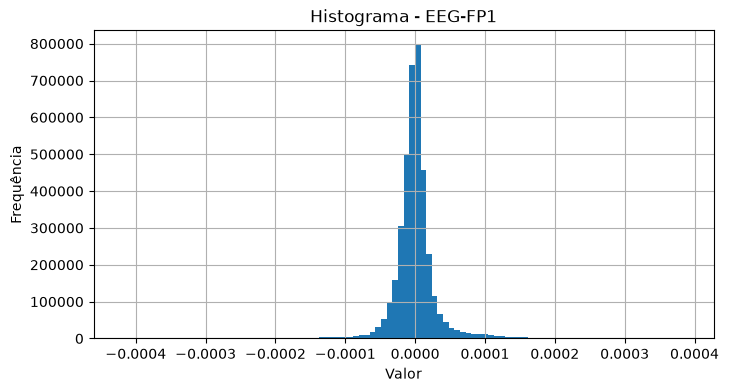

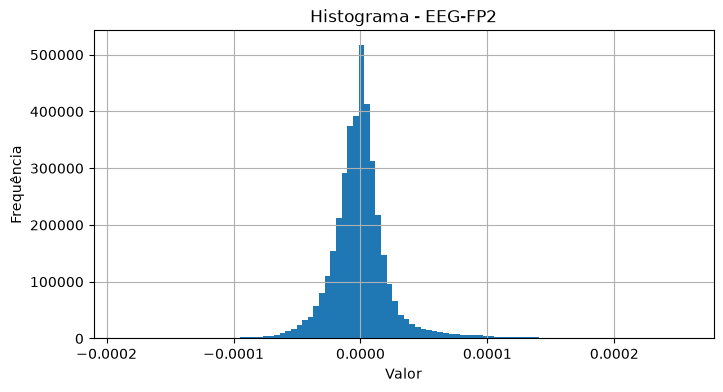

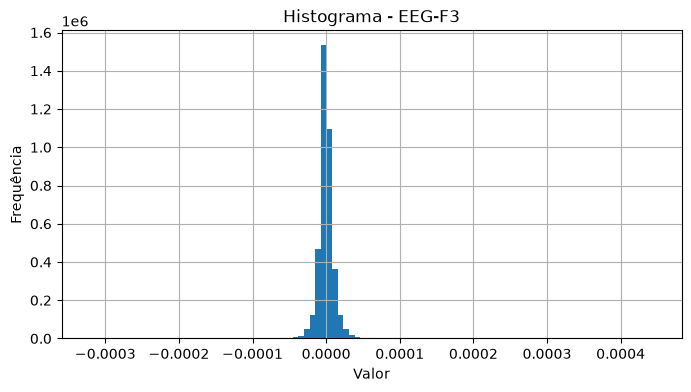

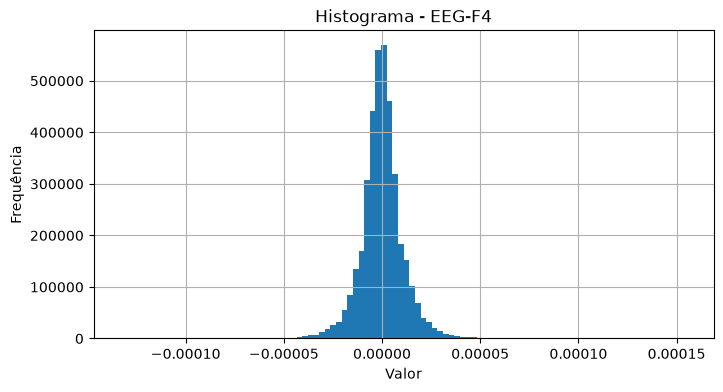

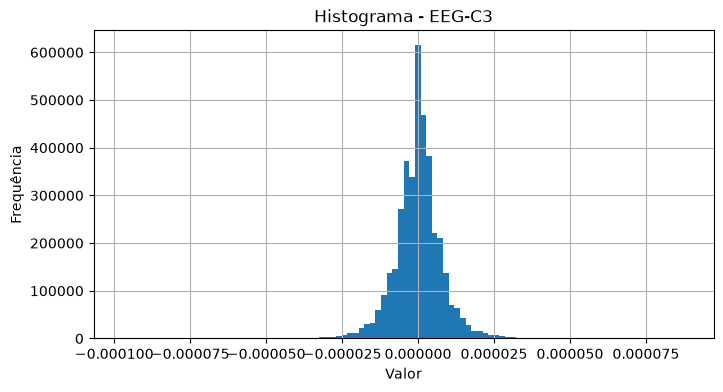

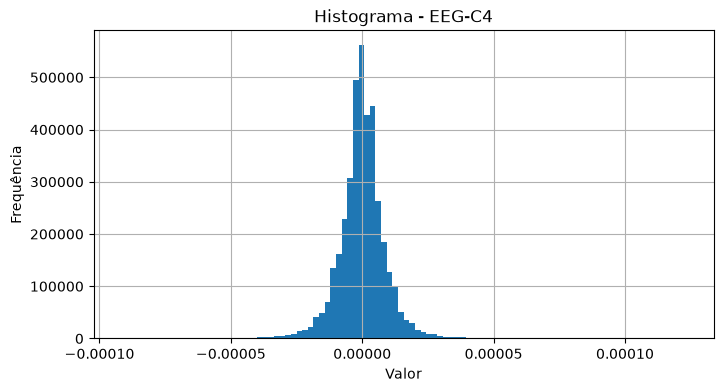

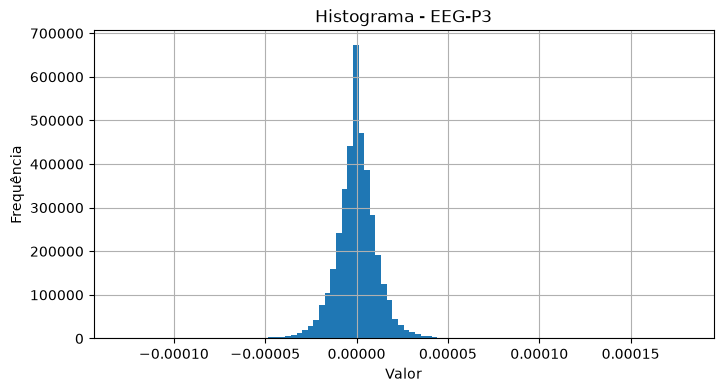

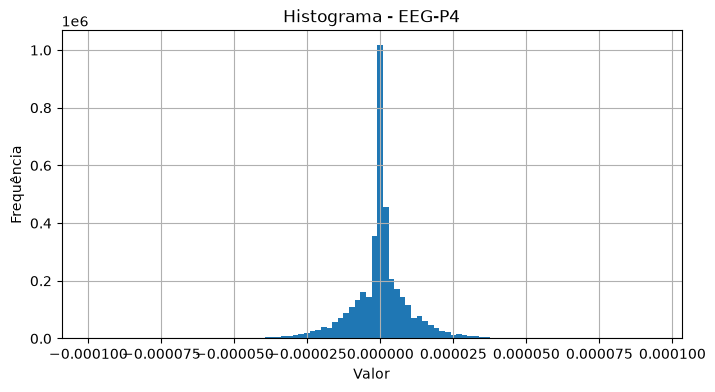

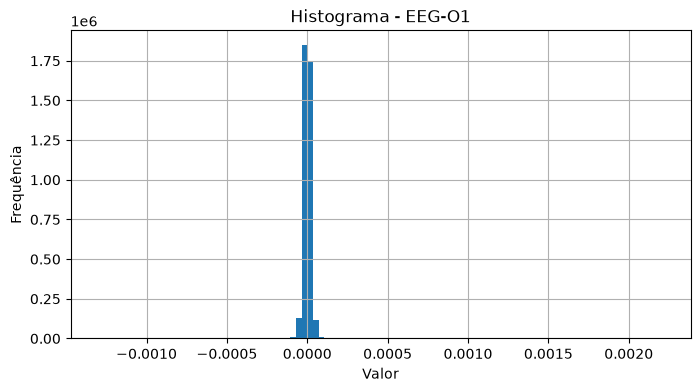

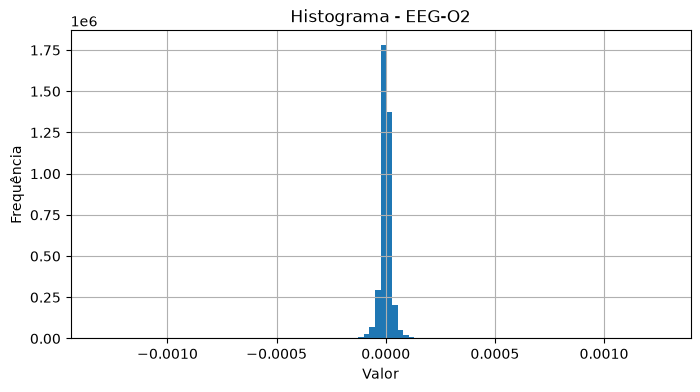

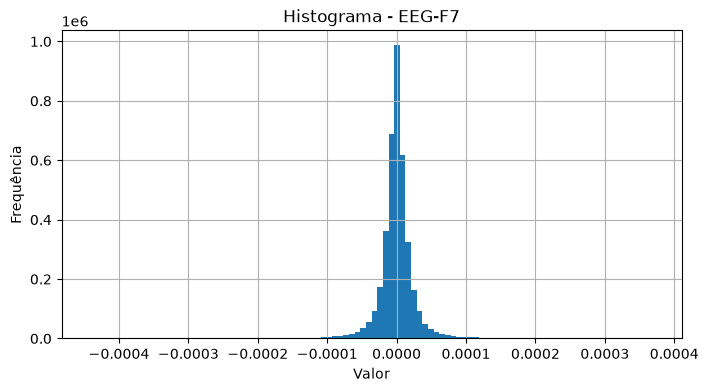

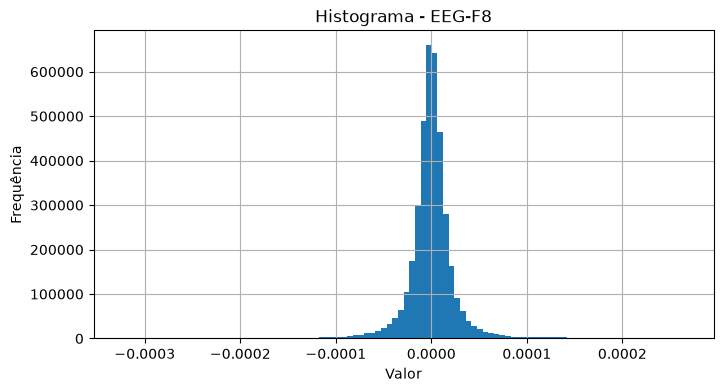

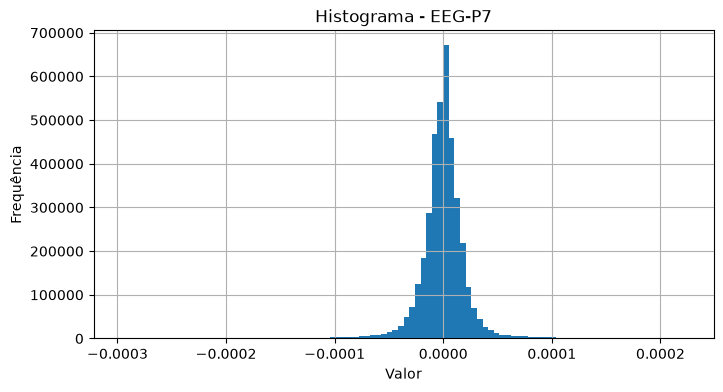

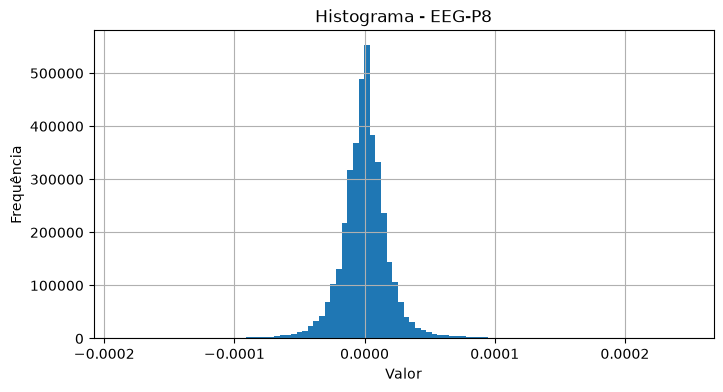

EEG-FZ: sem dados válidos
EEG-CZ: sem dados válidos
EEG-PZ: sem dados válidos


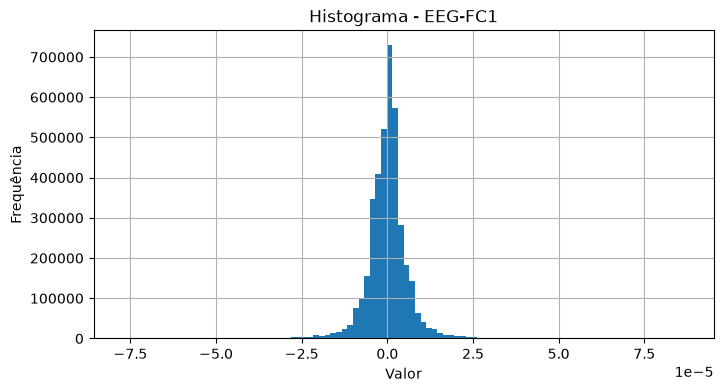

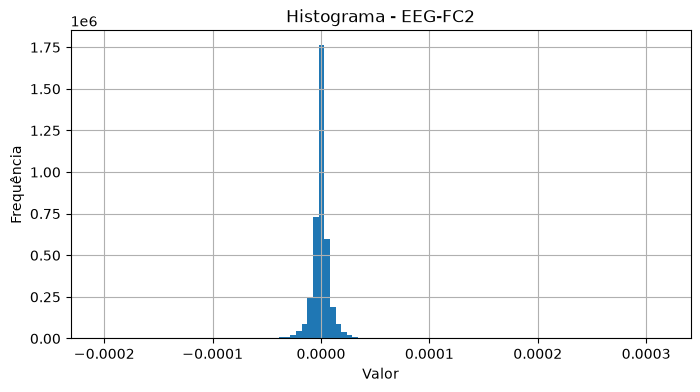

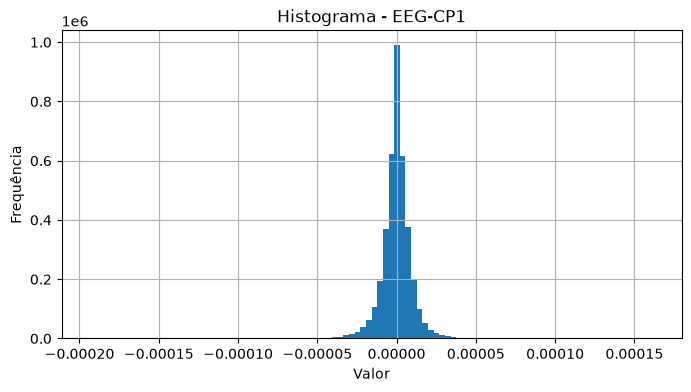

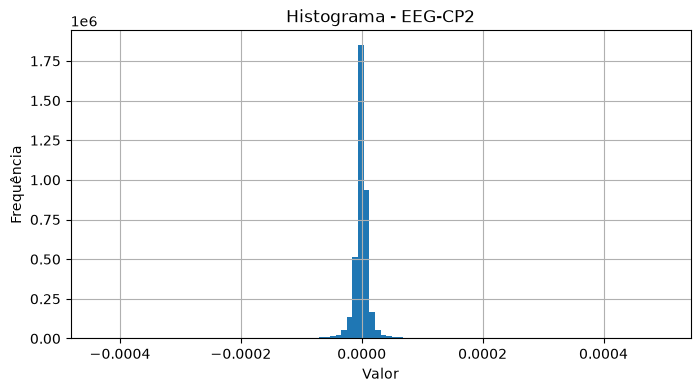

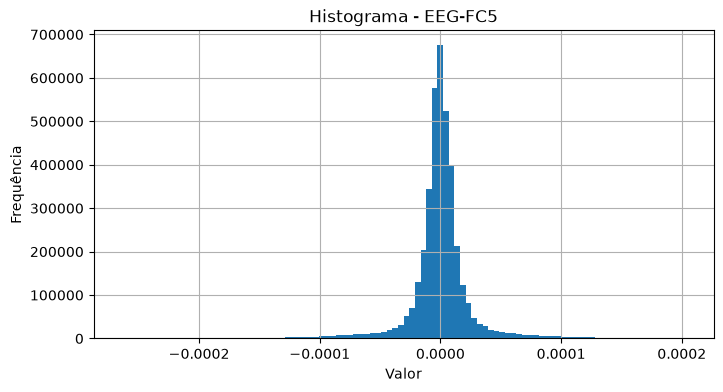

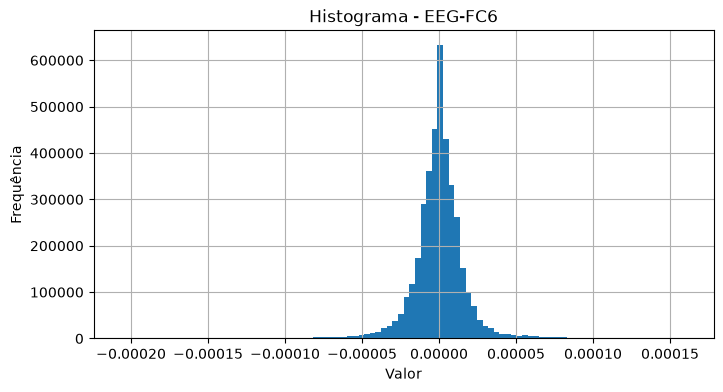

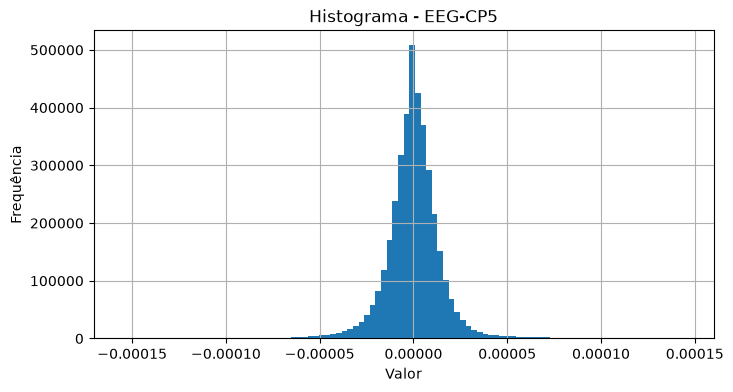

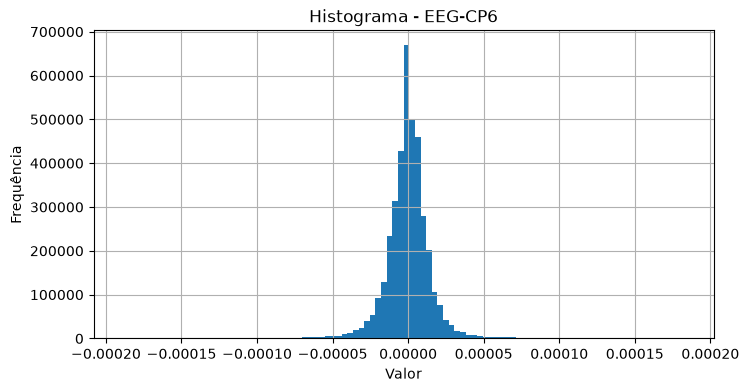

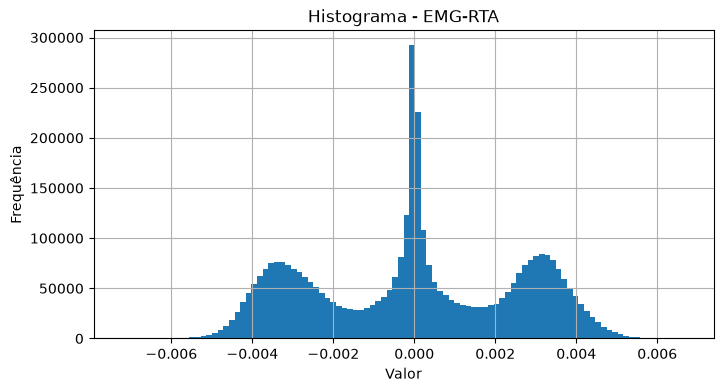

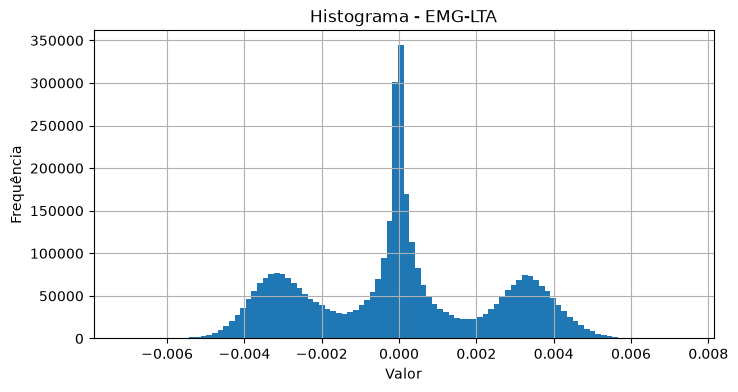

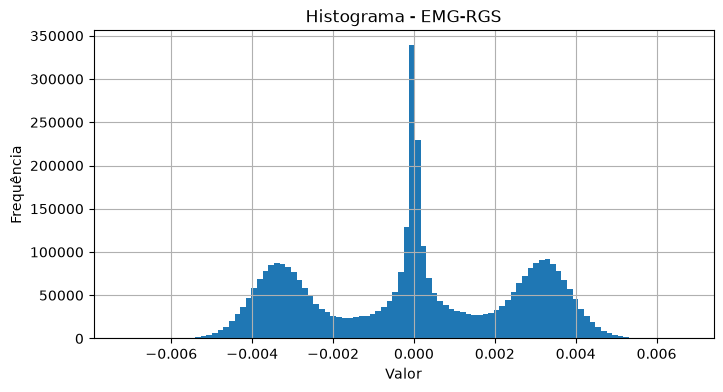

IO: sem dados válidos


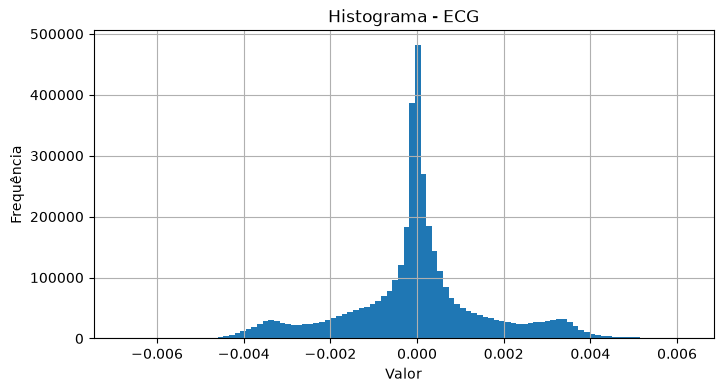

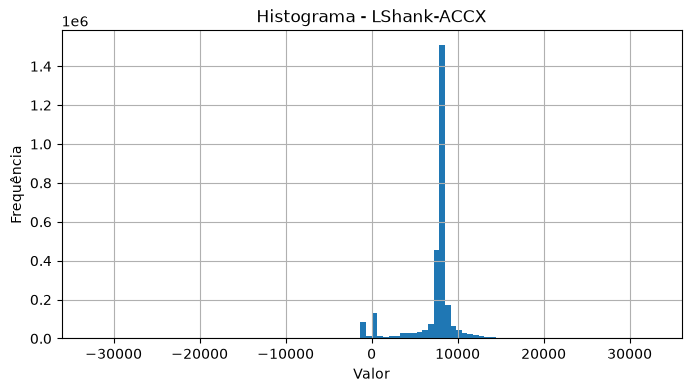

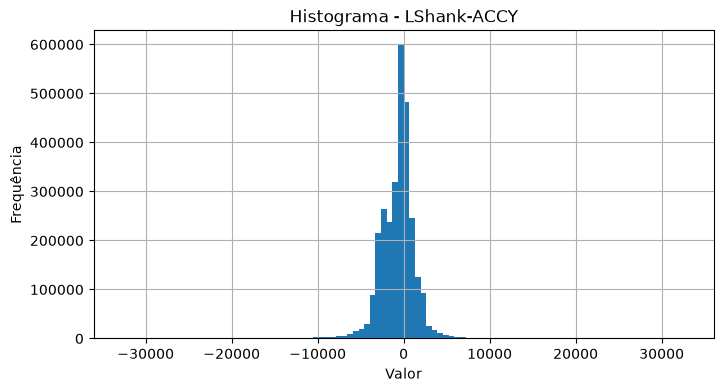

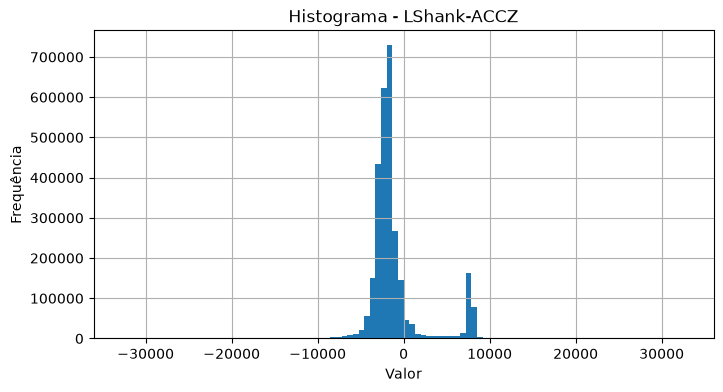

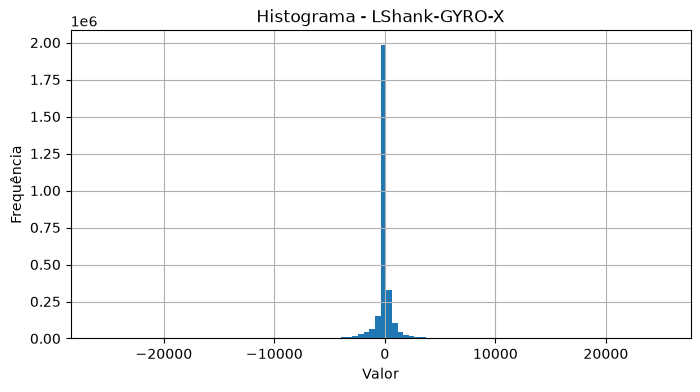

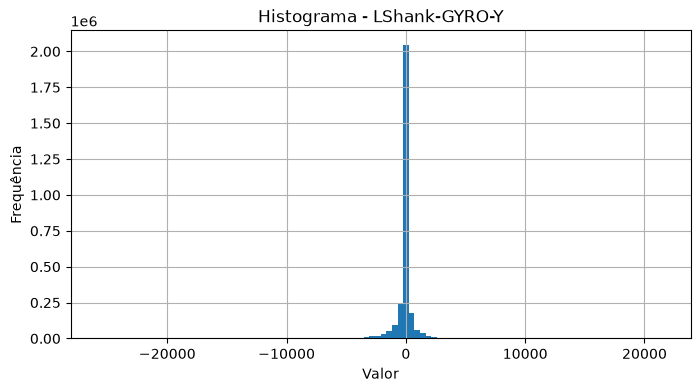

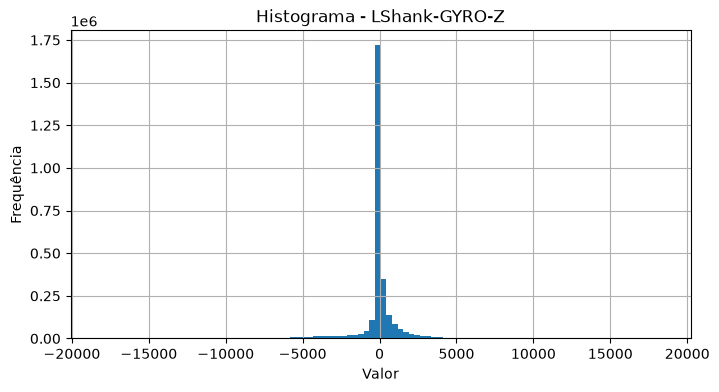

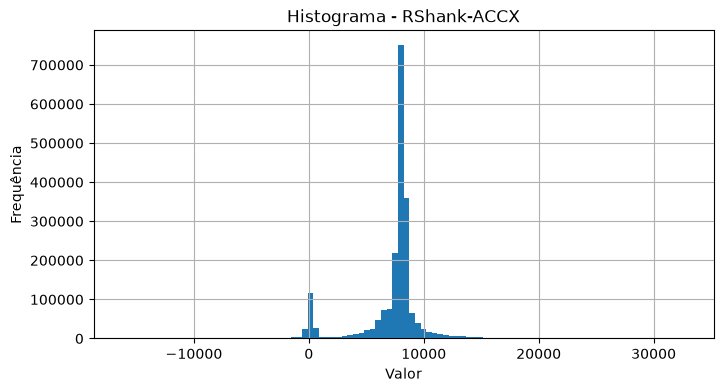

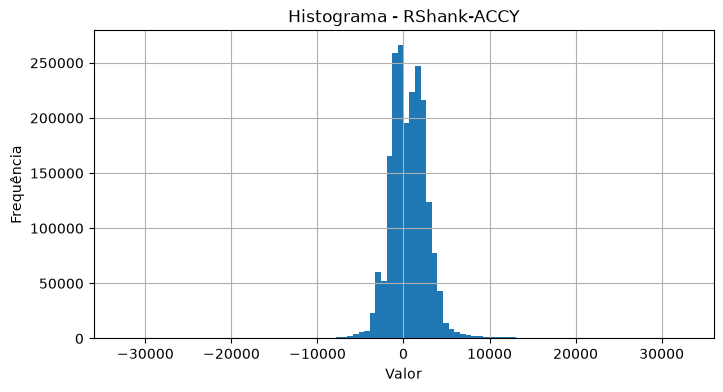

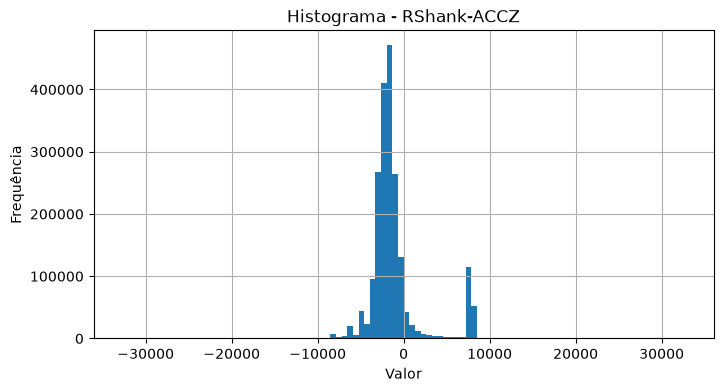

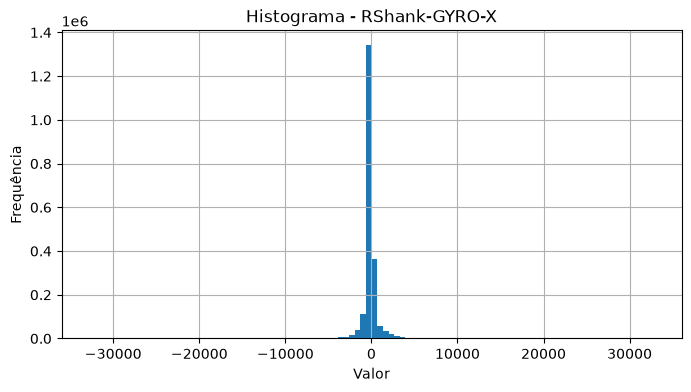

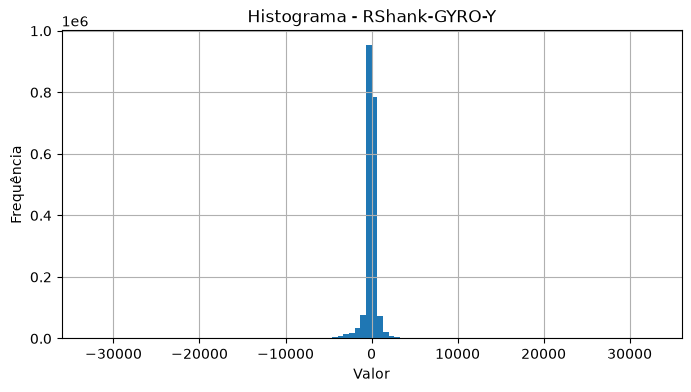

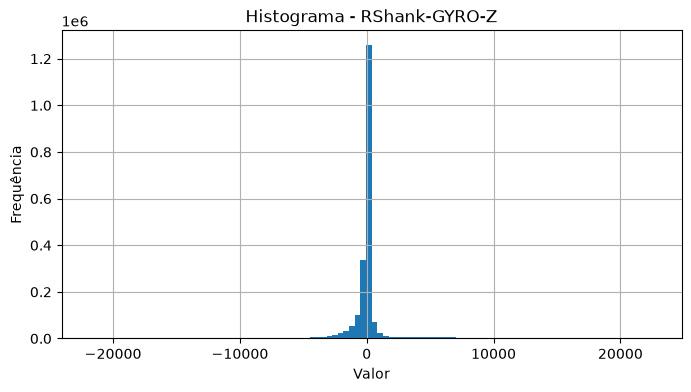

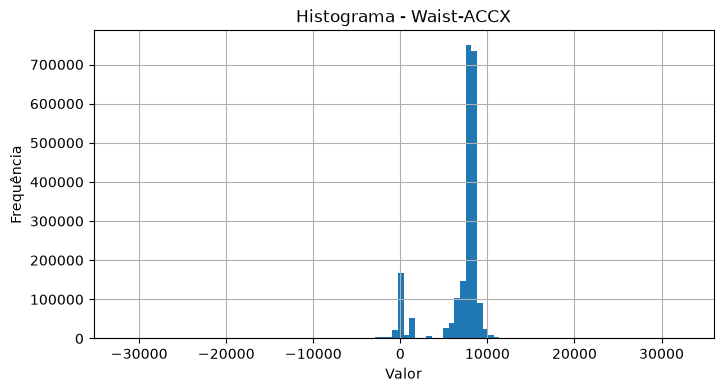

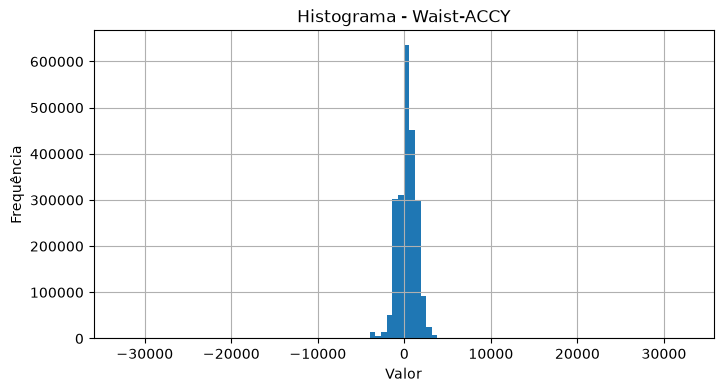

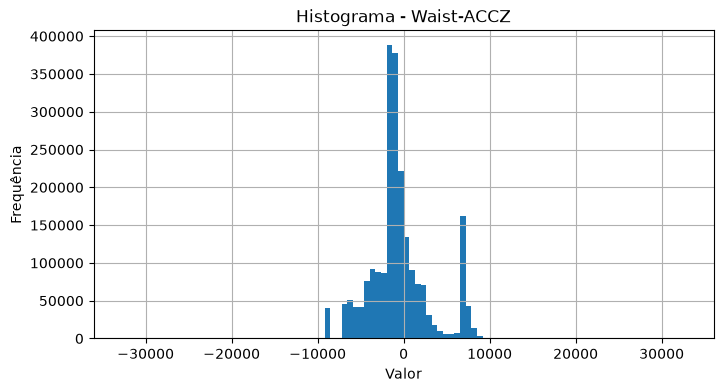

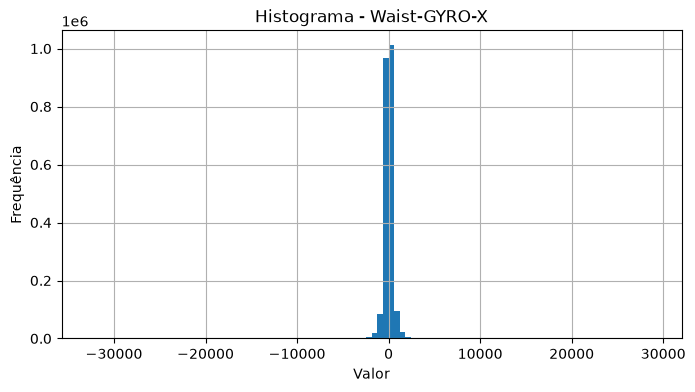

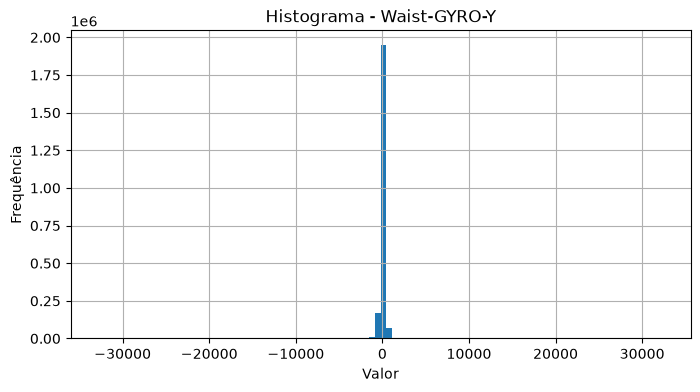

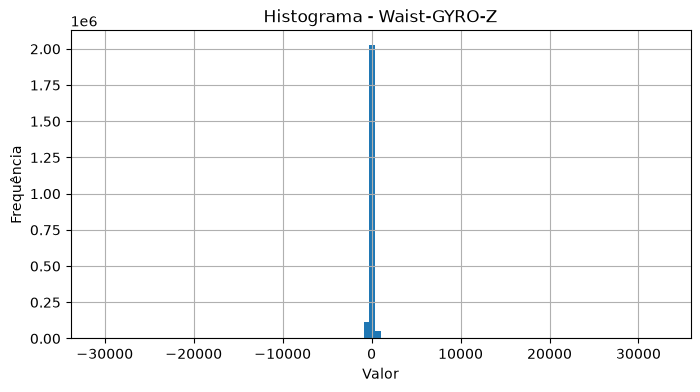

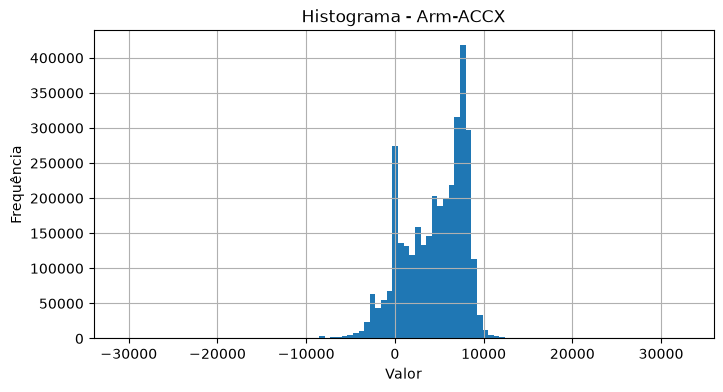

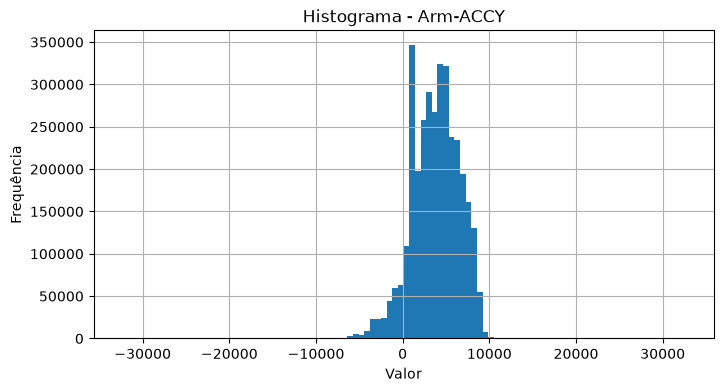

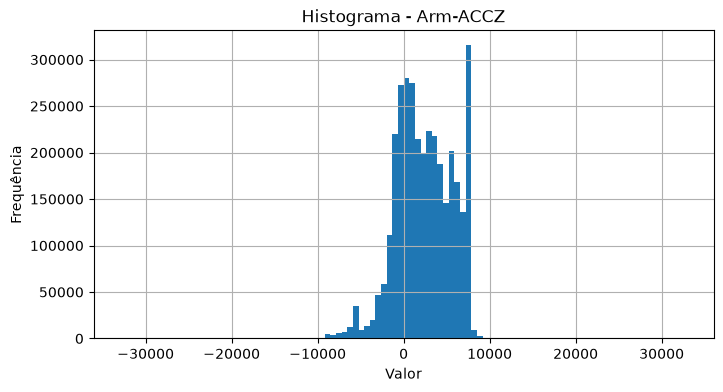

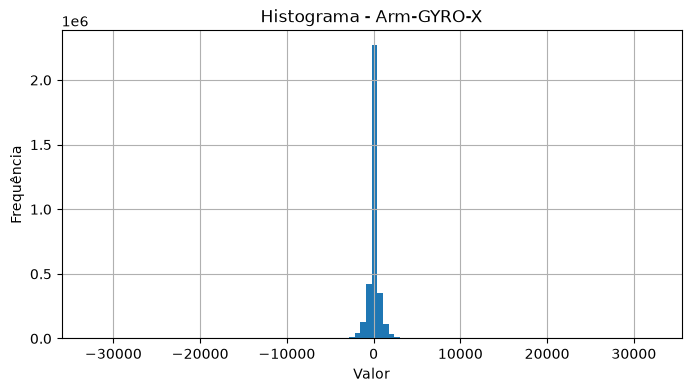

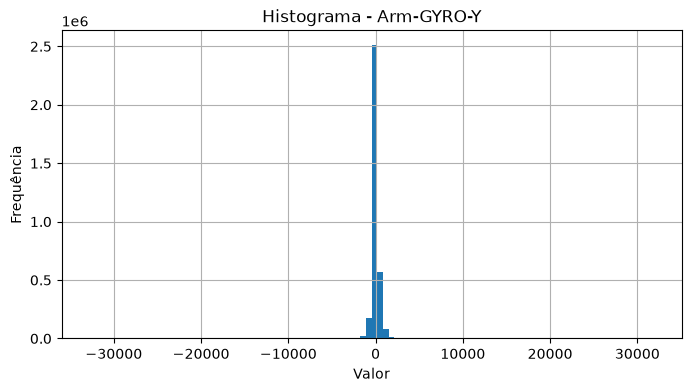

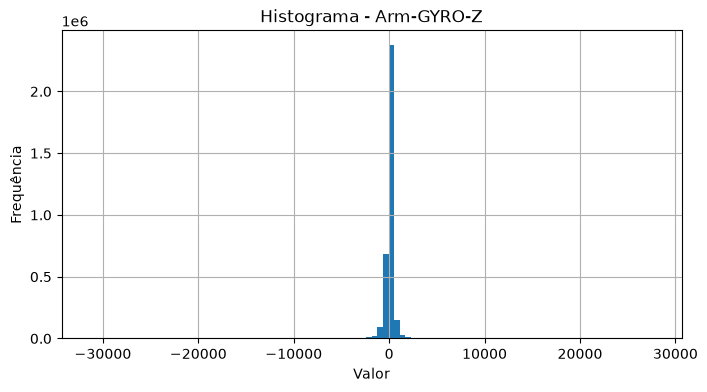

In [5]:
import matplotlib.pyplot as plt
import numpy as np

signal_cols = [
    col for col in df.columns
    if any(tag in col for tag in ["EEG", "EMG", "ACC", "GYRO", "ECG", "IO"])
]

def clean_series(series):
    data = series.replace([np.inf, -np.inf], np.nan).dropna()
    return data

for col in signal_cols:
    if col in df.columns:
        data = clean_series(df[col])

        if data.empty:
            print(f"{col}: sem dados válidos")
            continue

        plt.figure(figsize=(8, 4))
        data.hist(bins=100)
        plt.title(f"Histograma - {col}")
        plt.xlabel("Valor")
        plt.ylabel("Frequência")
        plt.show()

## 3. Boxplot (Detecção de Outliers)

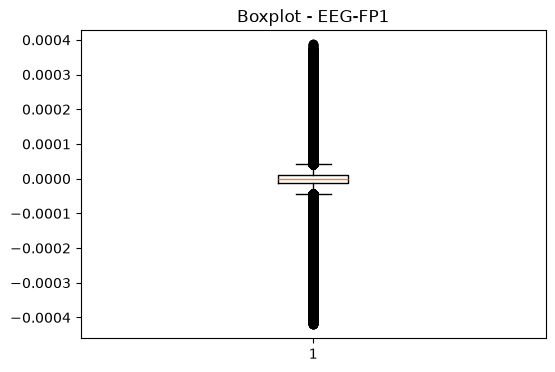

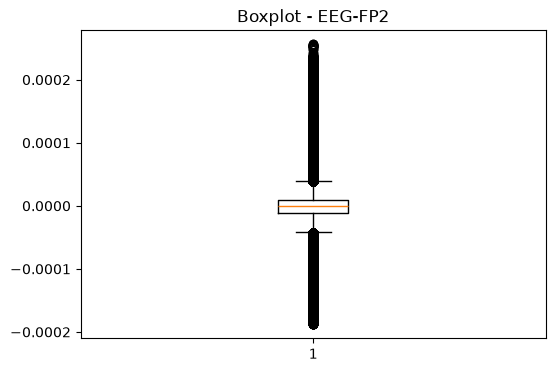

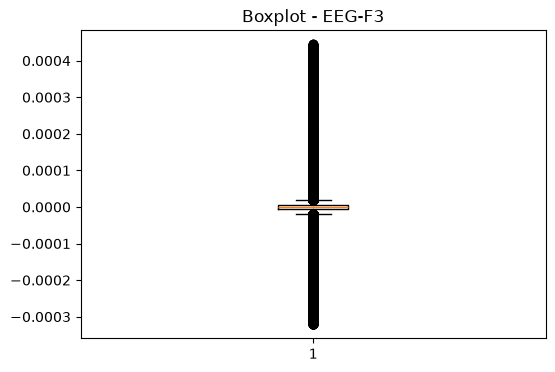

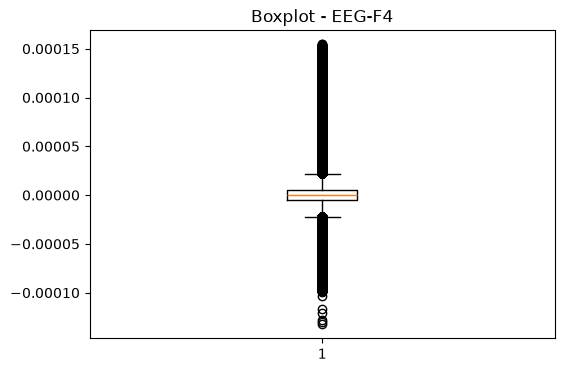

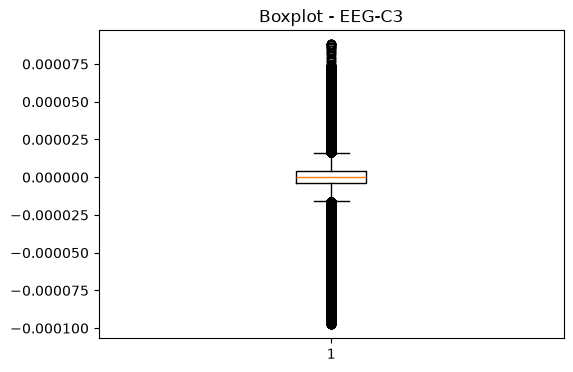

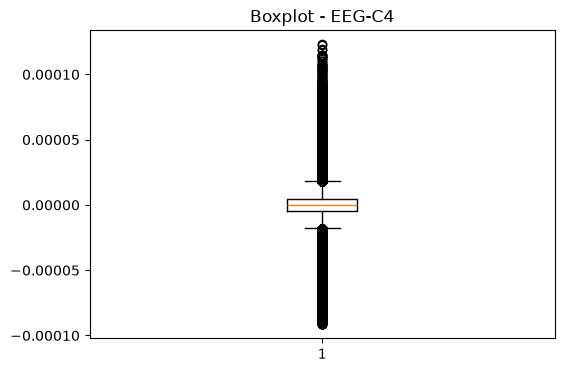

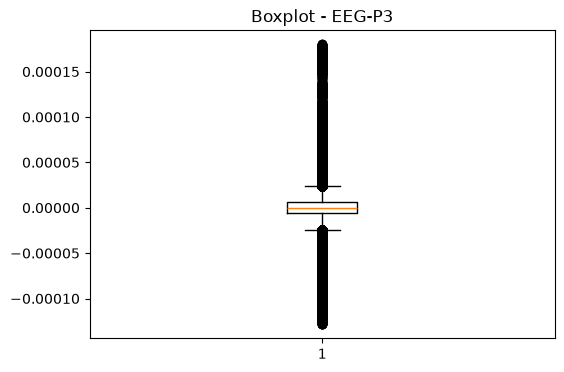

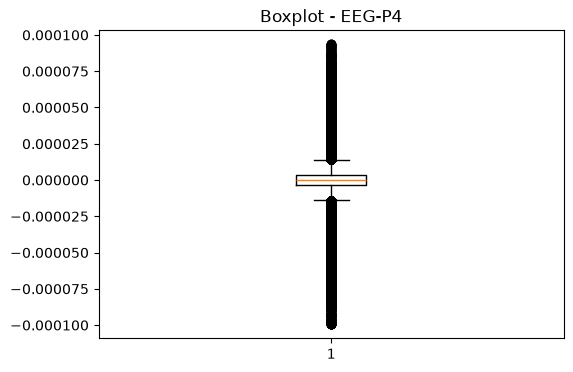

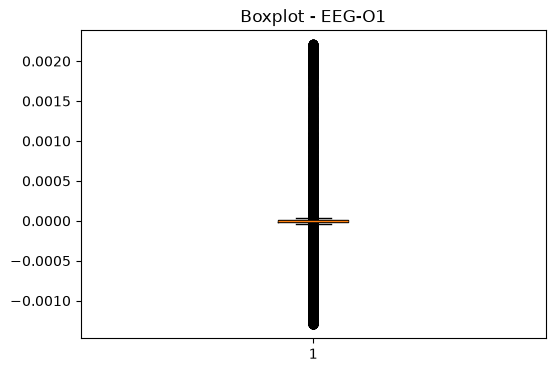

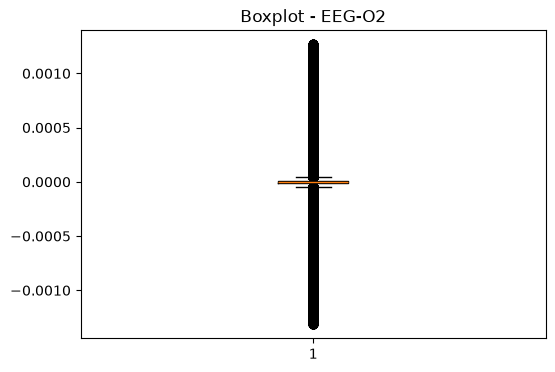

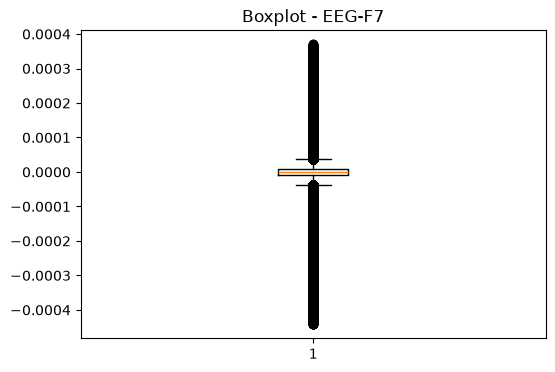

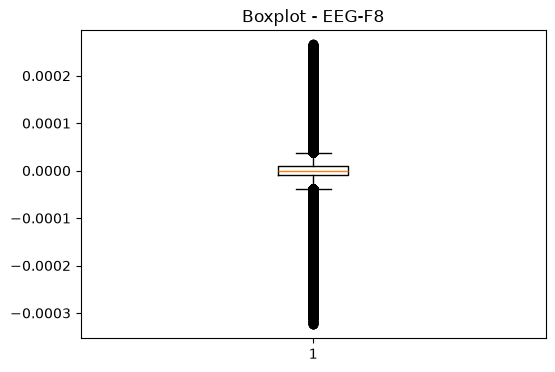

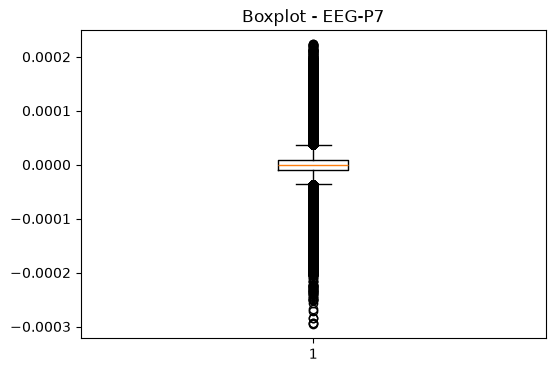

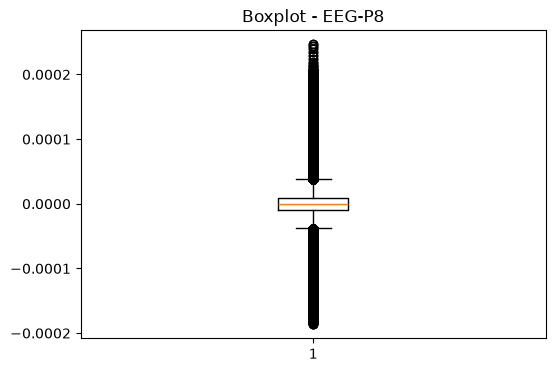

EEG-FZ: sem dados válidos
EEG-CZ: sem dados válidos
EEG-PZ: sem dados válidos


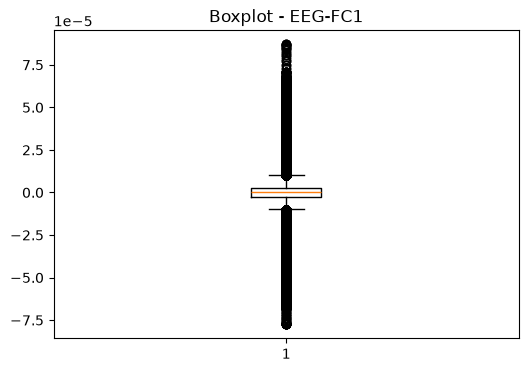

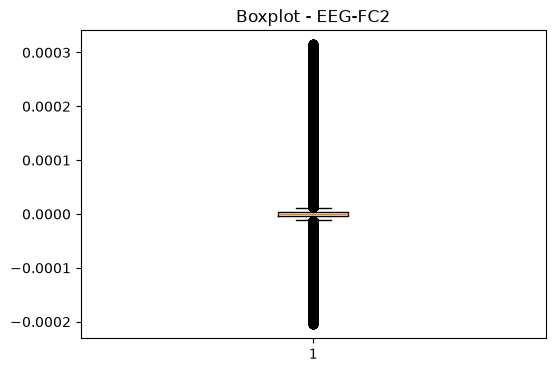

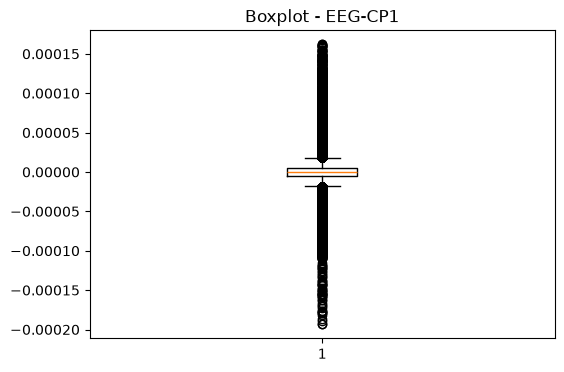

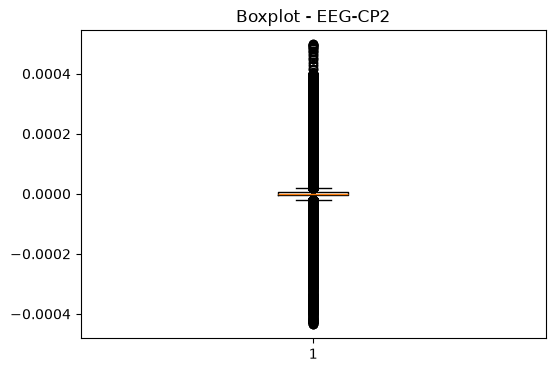

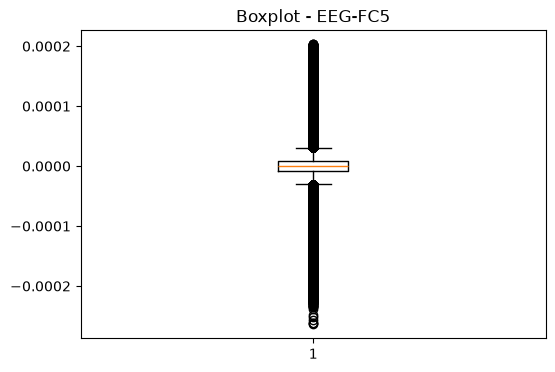

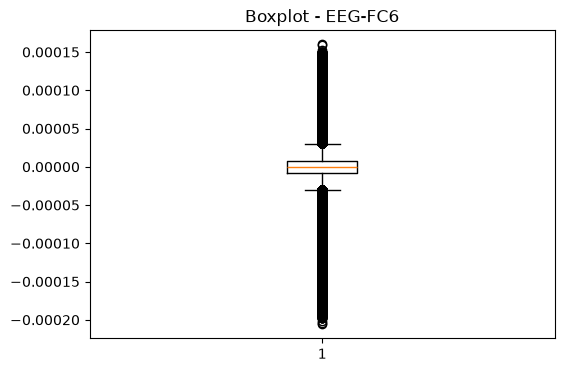

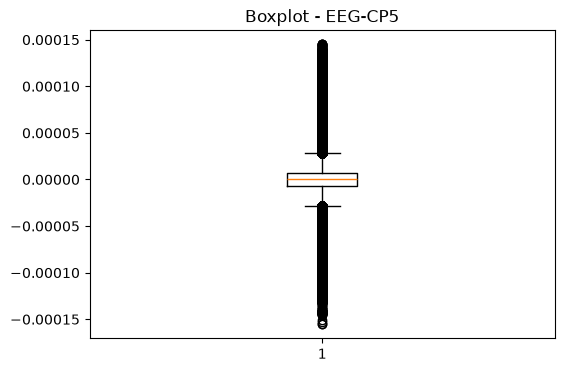

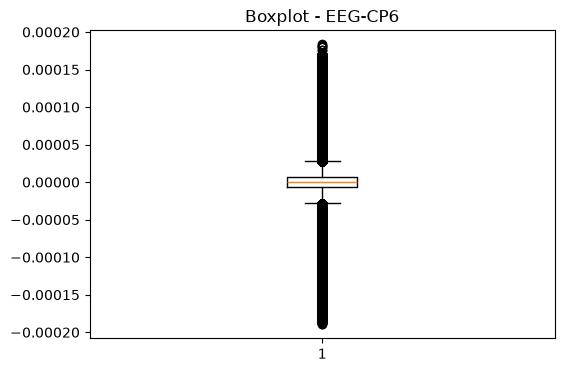

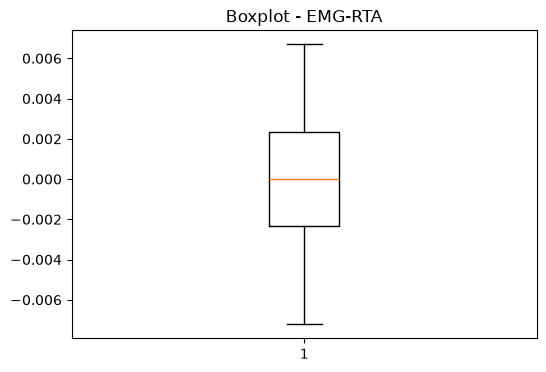

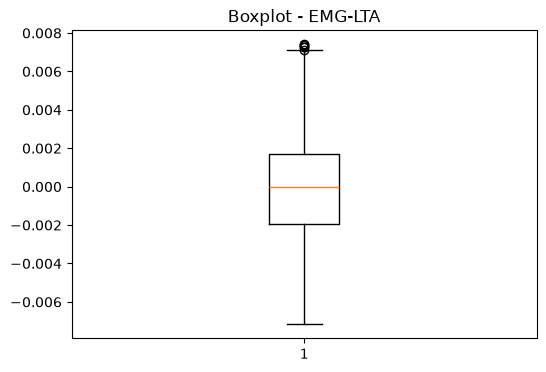

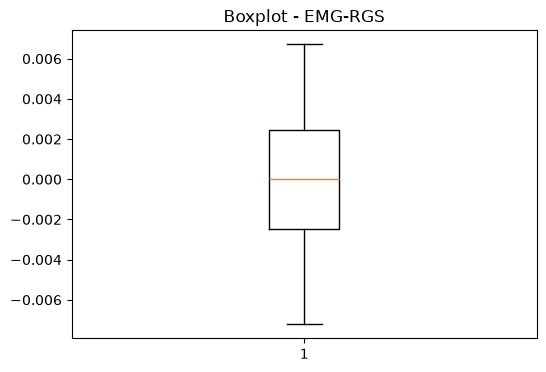

IO: sem dados válidos


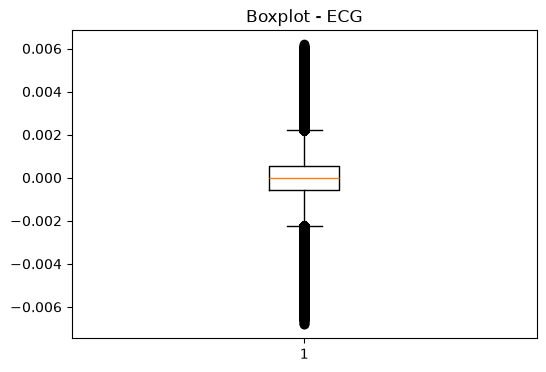

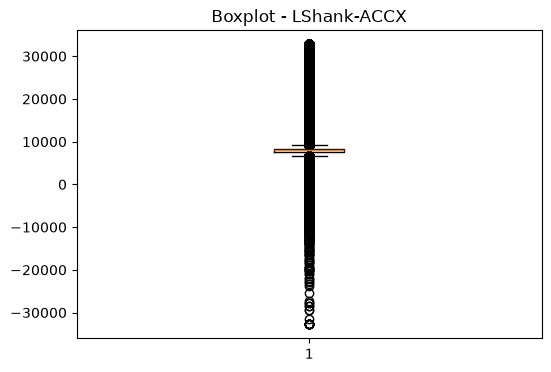

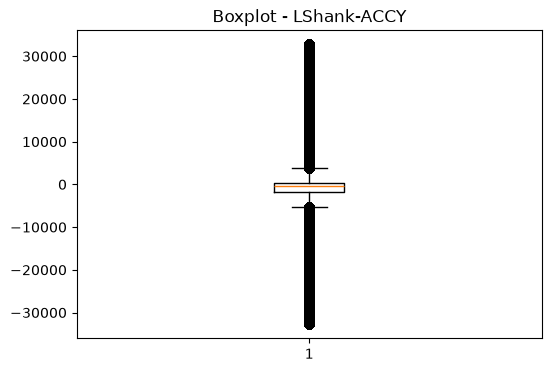

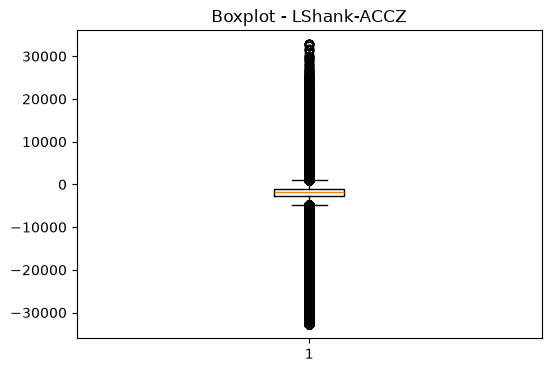

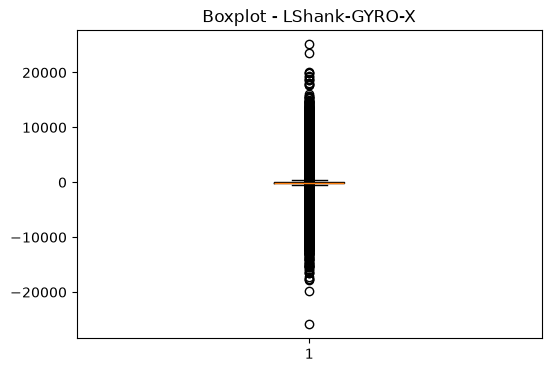

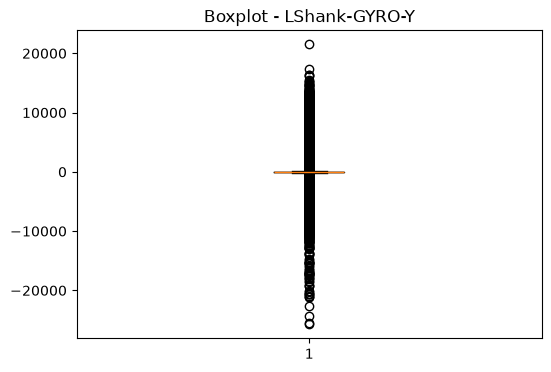

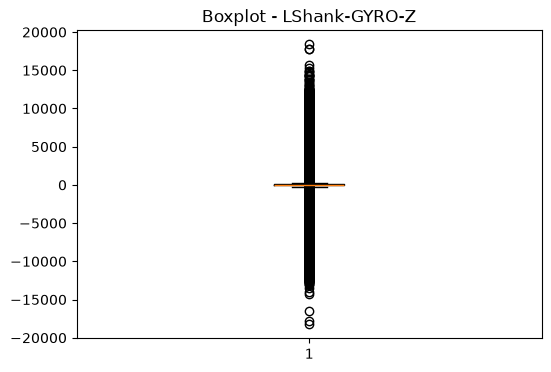

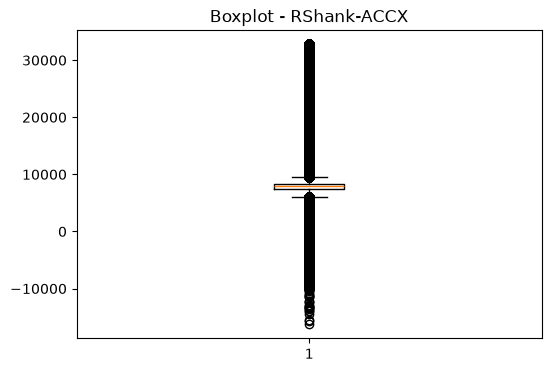

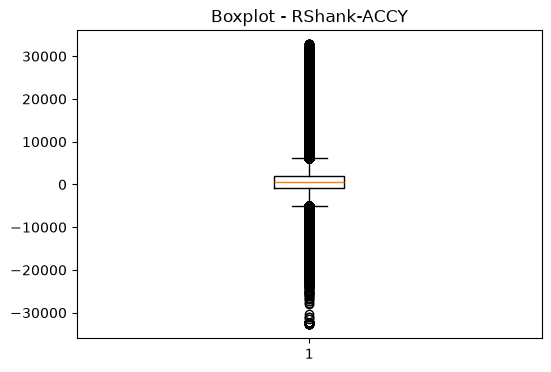

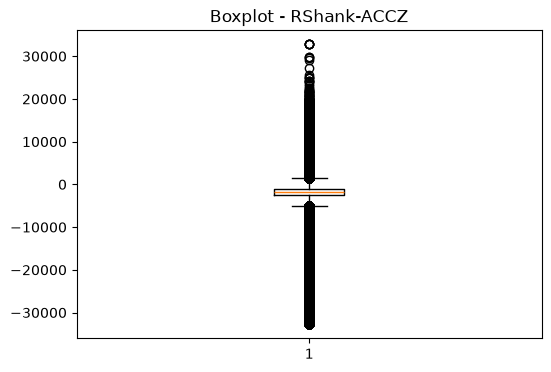

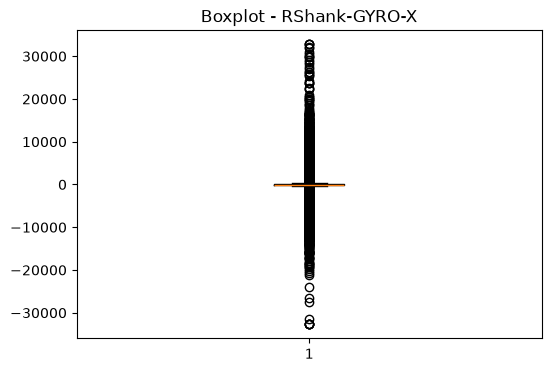

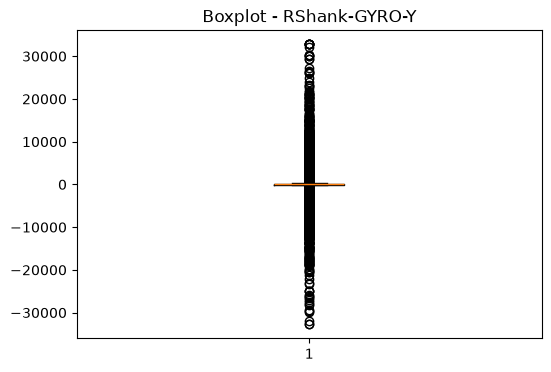

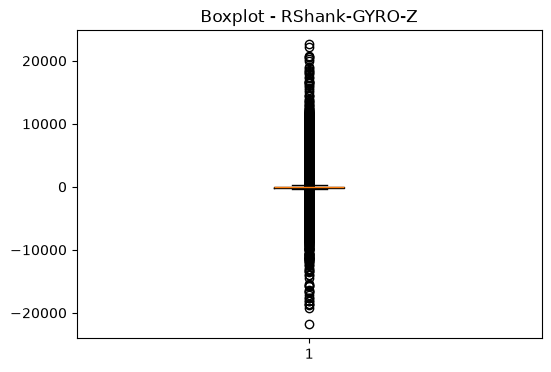

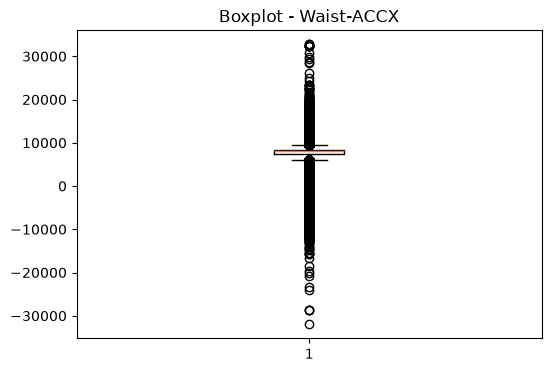

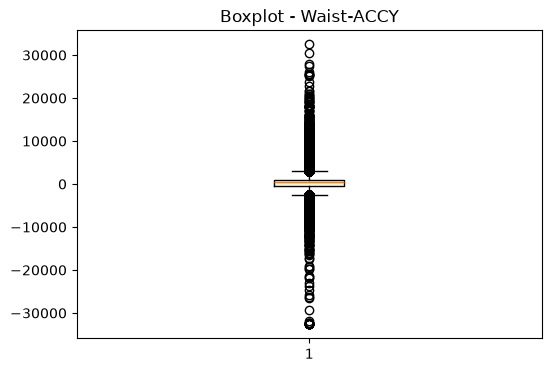

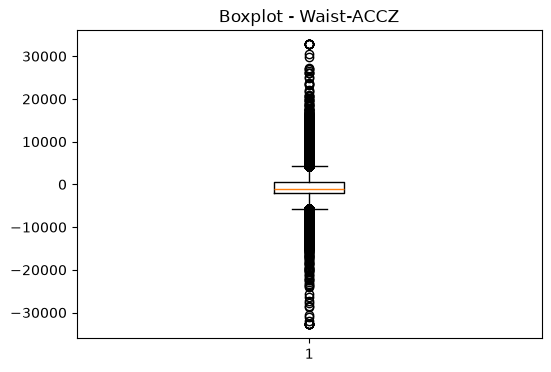

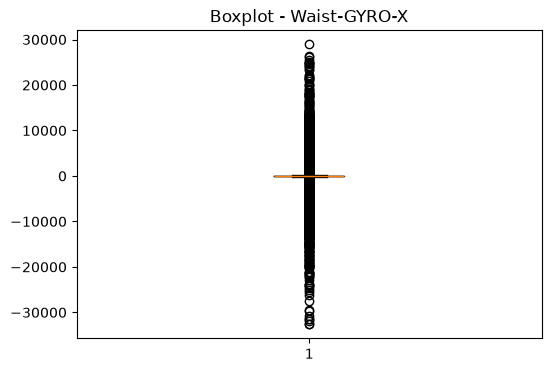

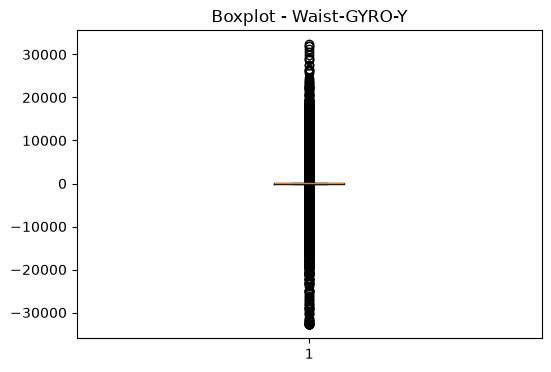

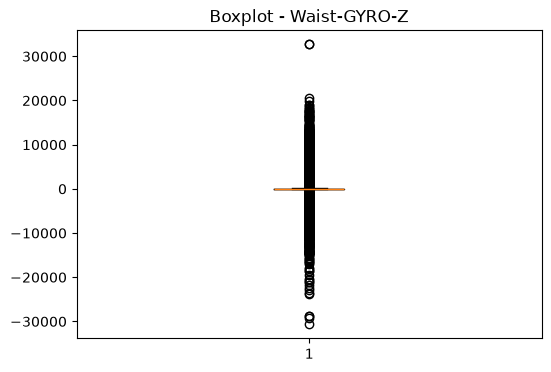

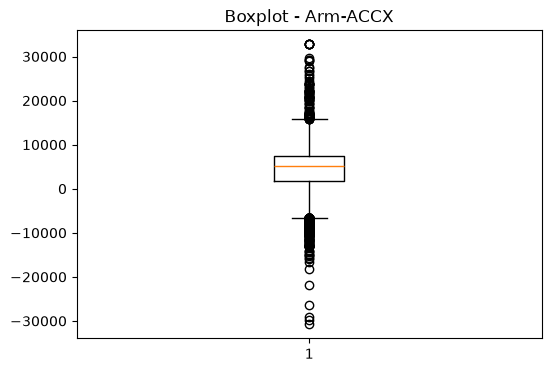

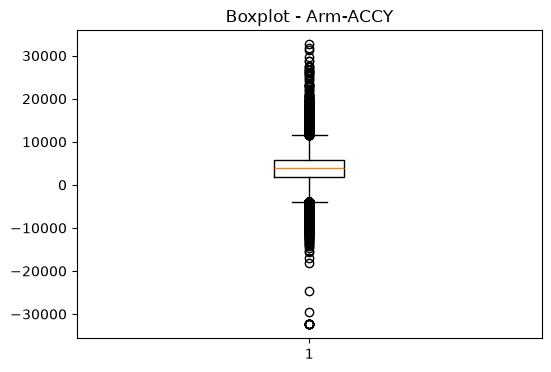

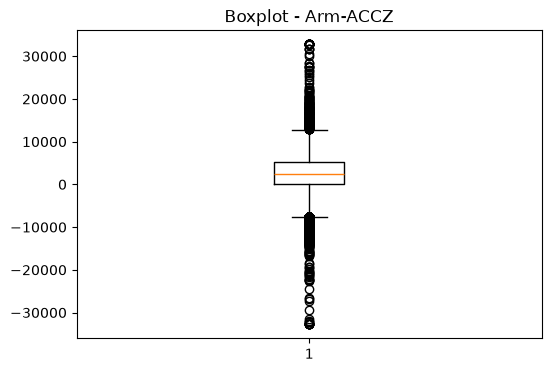

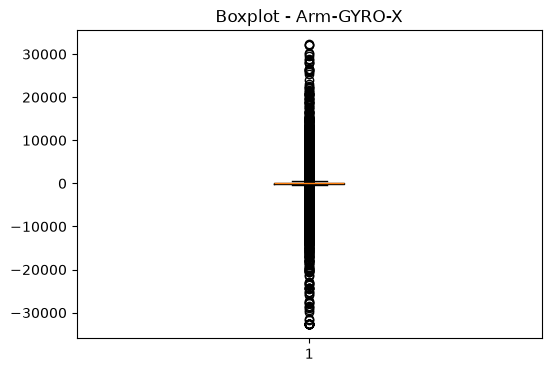

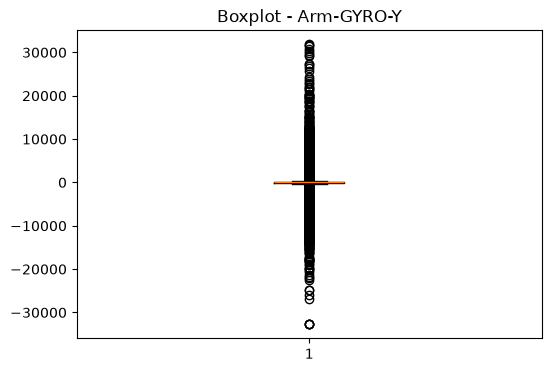

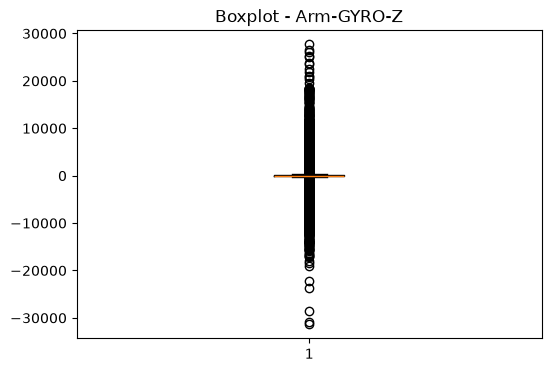

In [6]:
for col in signal_cols:
    if col in df.columns:
        data = clean_series(df[col])

        if data.empty:
            print(f"{col}: sem dados válidos")
            continue

        plt.figure(figsize=(6, 4))
        plt.boxplot(data)
        plt.title(f"Boxplot - {col}")
        plt.show()


## Interpretação de alguns dos Sinais EEG

Os sinais de EEG (como FP1, C3 e O1) apresentam características típicas de atividade cerebral:

* **EEG-FP1**: apresenta pequenas variações centradas em torno de 0, com amplitude entre aproximadamente -0.0002 e +0.0002. Isso indica um sinal de baixa amplitude, como esperado em EEGs.
* **EEG-C3**: possui amplitude um pouco menor (±0.000025), sugerindo menor atividade ou variação nessa região cerebral.
* **EEG-O1**: apresenta ainda maior amplitude (±0.0005), o que pode indicar maior variabilidade ou sensibilidade a ruídos/artifícios.

Em geral, sinais de EEG:

* são centrados próximos de zero
* têm baixa amplitude
* representam atividade elétrica cerebral muito sutil

---

## Interpretação do EMG (EMG-RTA)

O sinal de EMG-RTA se comporta de forma bem diferente:

* Apresenta uma estrutura semelhante a uma “montanha” com três picos principais.
* Os picos laterais atingem cerca de ±0.003 com o lado positivo um pouco maior que o negativo.
* O pico central ocorre em uma frequência mais alta (~200.000), indicando uma contração muscular mais intensa ou rápida.

Interpretação:

* EMG mede atividade muscular → naturalmente tem amplitudes maiores que EEG.
* Os picos representam momentos de ativação muscular.
* A forma do sinal sugere eventos específicos de movimento.

---

## Interpretação dos Acelerômetros

Os histogramas dos acelerômetros mostram:

* Presença de valores negativos → **isso é totalmente normal**

  * Acelerômetros medem direção → valores negativos indicam movimento no sentido oposto.
* Maior concentração de valores positivos
* Picos que chegam até valores próximos de 10.000

Interpretação:

* Esses valores podem estar em unidades brutas do sensor (não normalizadas)
* Ou representam aceleração em alguma escala interna (ex: LSB do sensor)

Ideal seria verificar:

* unidade (m/s²? valor bruto?)
* necessidade de normalização

---

## Interpretação dos Boxplots

Observações:

* Muitos outliers nos sinais de sensores (principalmente acelerômetros e EEG)
* O EMG-RTA praticamente não apresenta outliers

Interpretação:

### Muitos outliers:

* comum em dados fisiológicos
* podem representar:

  * ruído
  * movimento brusco
  * eventos reais (ex: tremores, mudanças rápidas)

### EMG sem outliers:

* pode indicar:

  * distribuição mais consistente
  * ou que os valores extremos já fazem parte do padrão do sinal

---

## Conclusão Geral

* EEG: sinais suaves, baixa amplitude, centrados em zero.
* EMG: sinais mais intensos, com picos claros de atividade muscular.
* Acelerômetros: dados direcionais, com valores positivos e negativos, possivelmente em escala bruta.
* Boxplots: presença de outliers é esperada em biosinais.

No geral, os dados parecem coerentes com o tipo de sinal medido, mas precisam de polimento que iremos fazer com os dados já filtrados:

* normalização
* filtragem
* análise mais profunda por frequência (FFT, espectro, etc.)

---


## 4. Visualização das Ondas (Time Series)

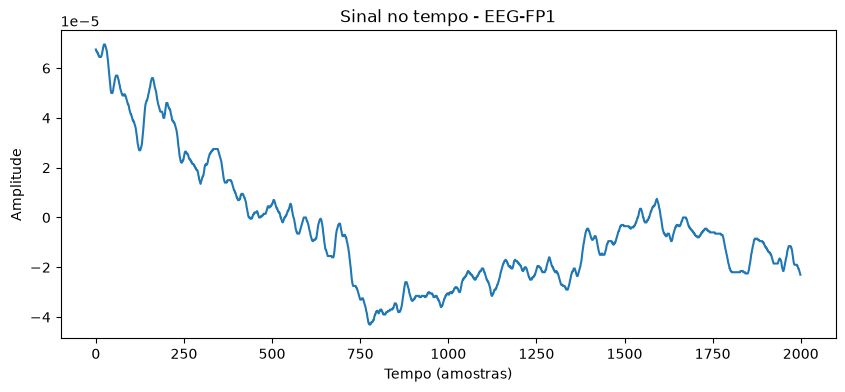

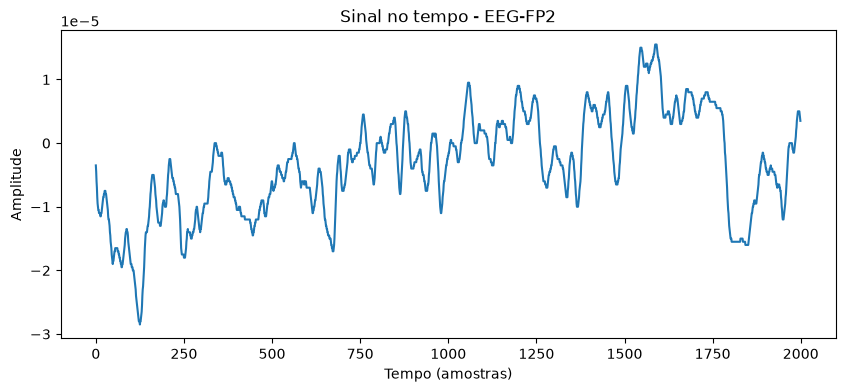

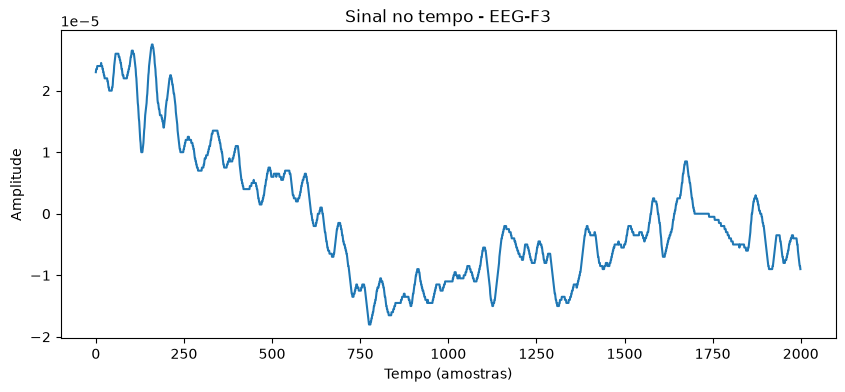

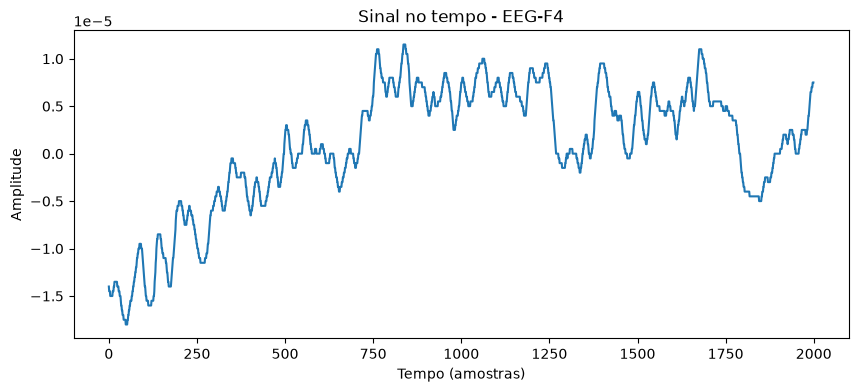

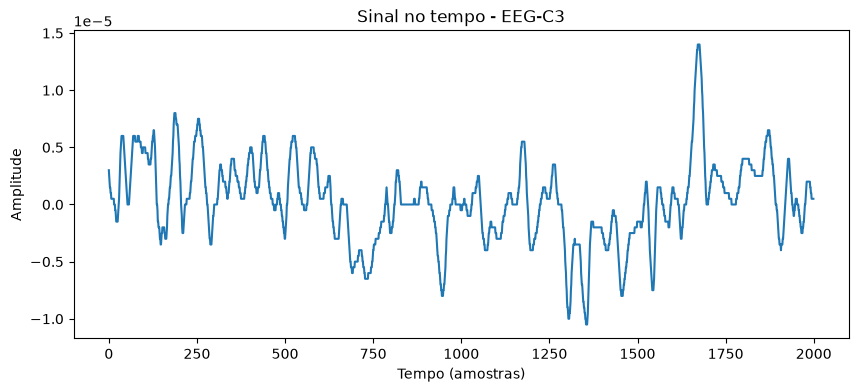

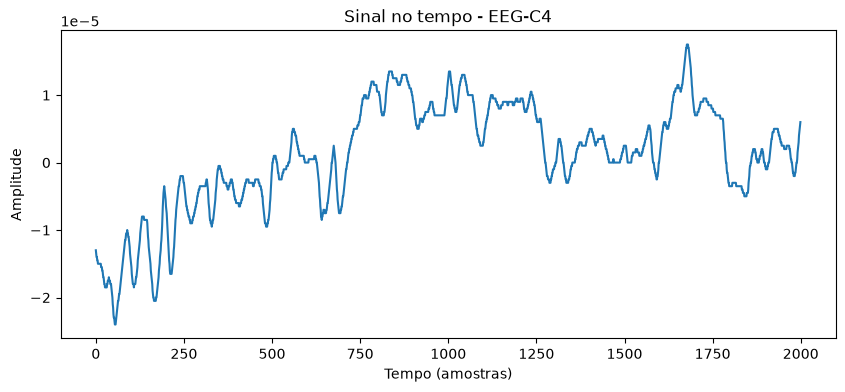

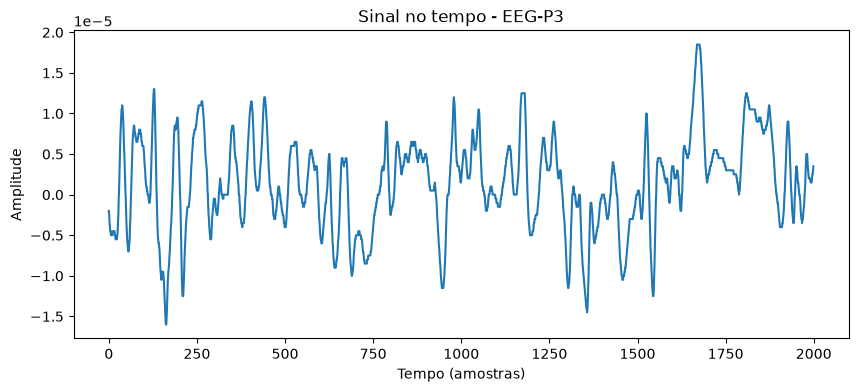

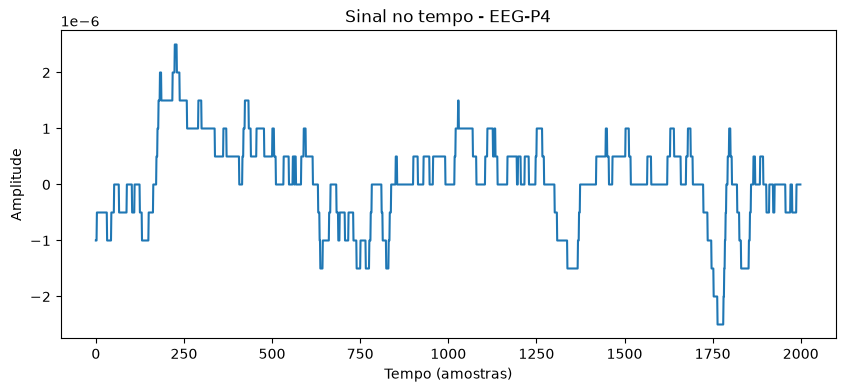

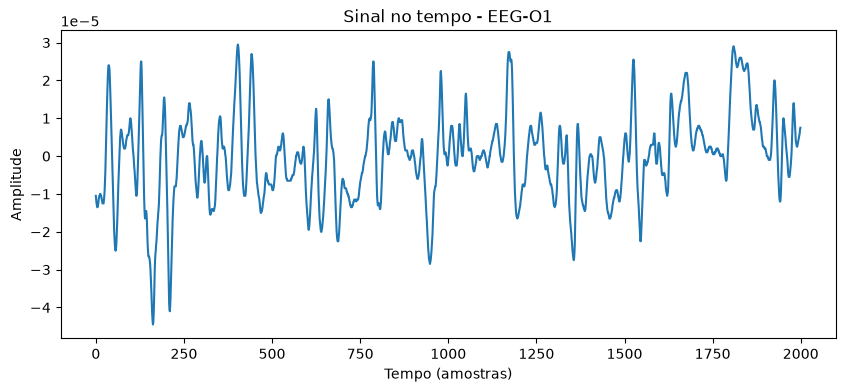

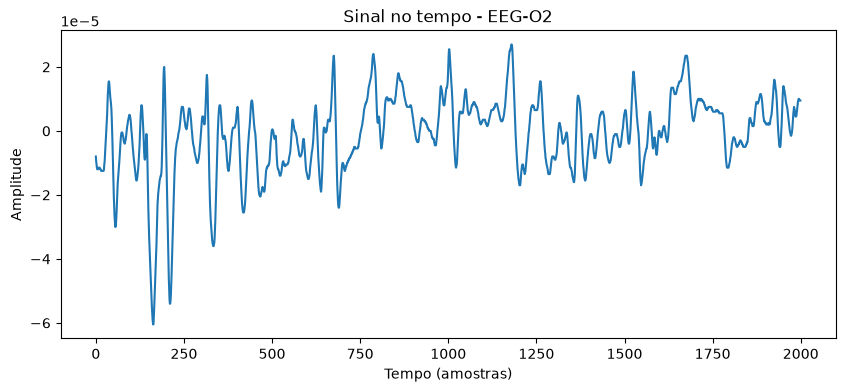

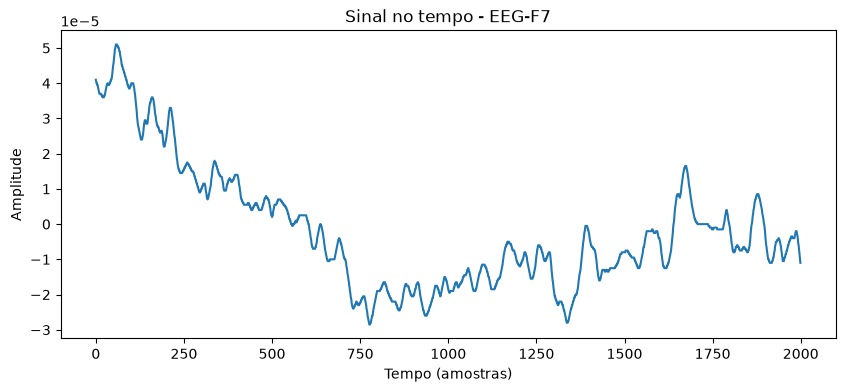

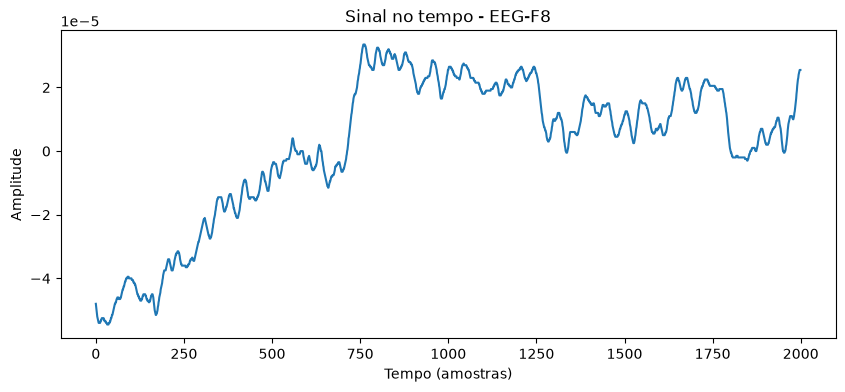

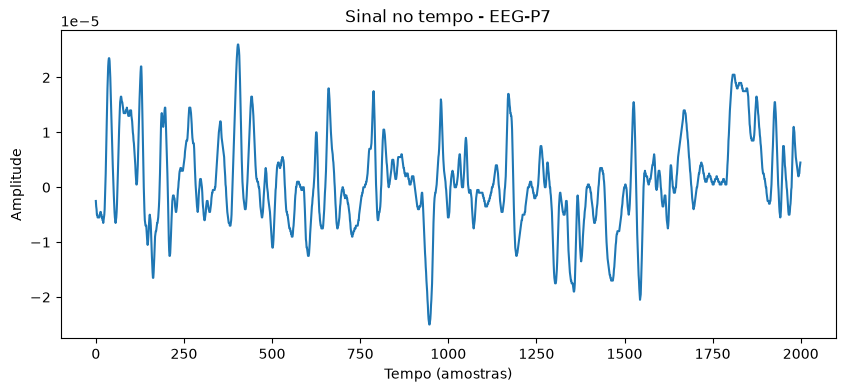

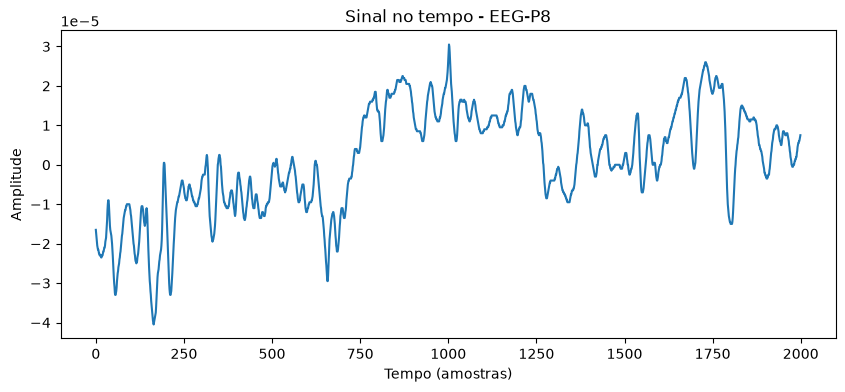

EEG-FZ: sem dados válidos
EEG-CZ: sem dados válidos
EEG-PZ: sem dados válidos


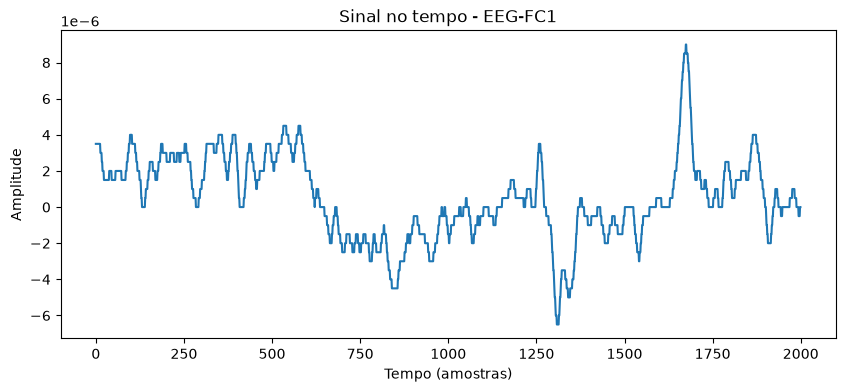

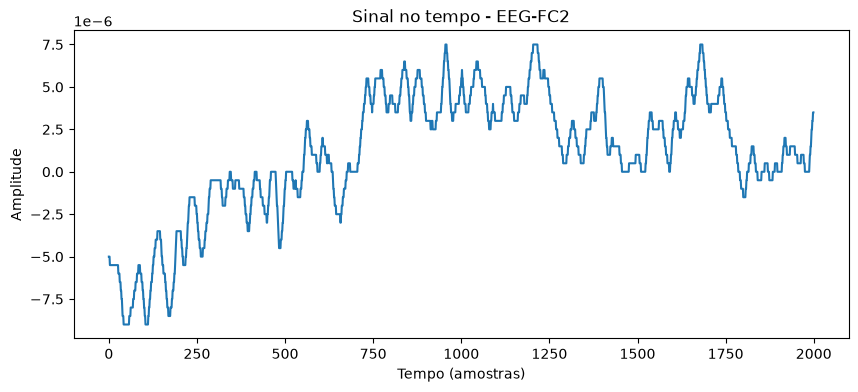

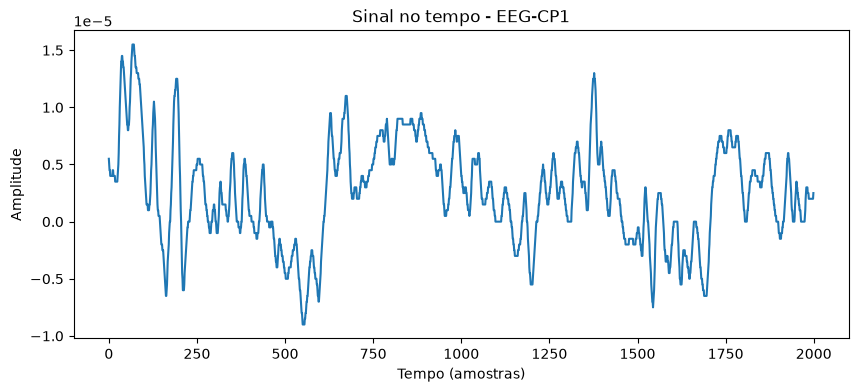

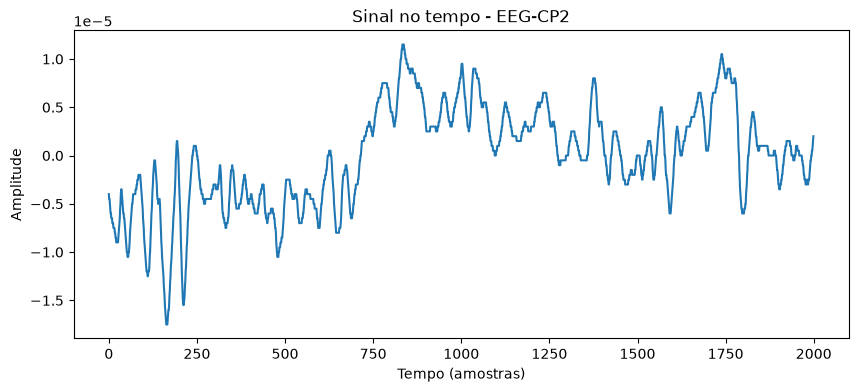

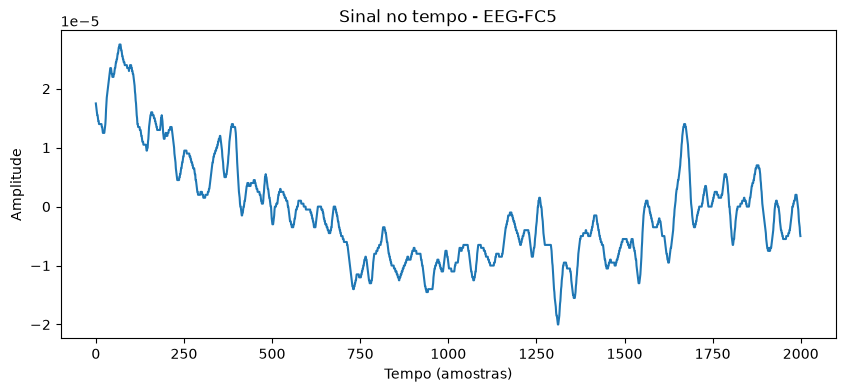

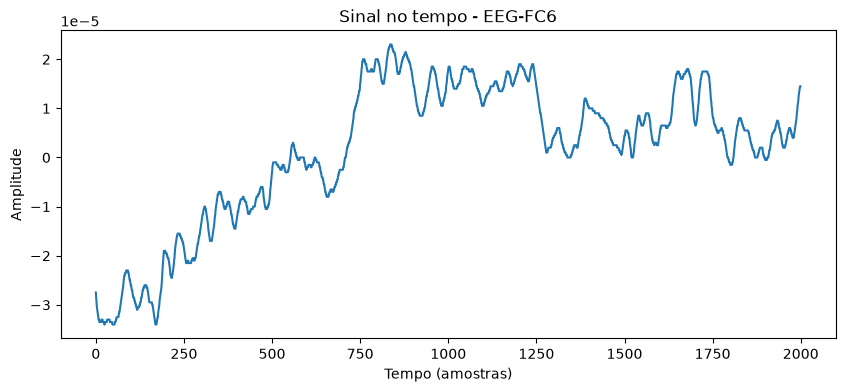

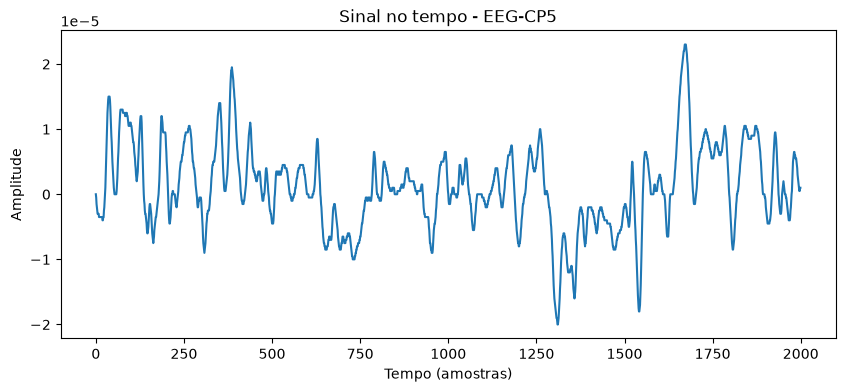

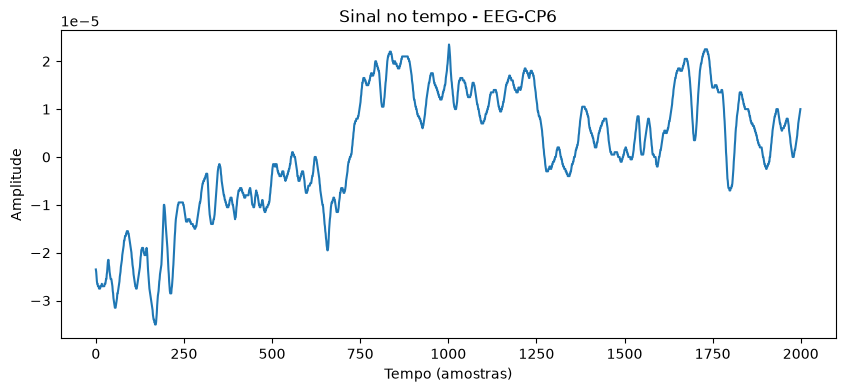

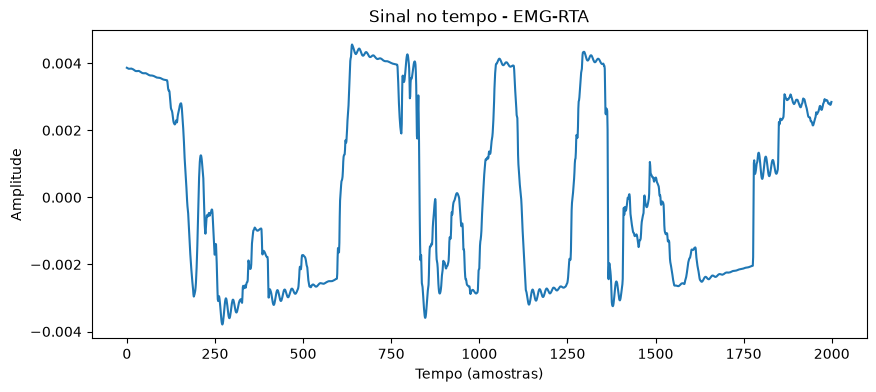

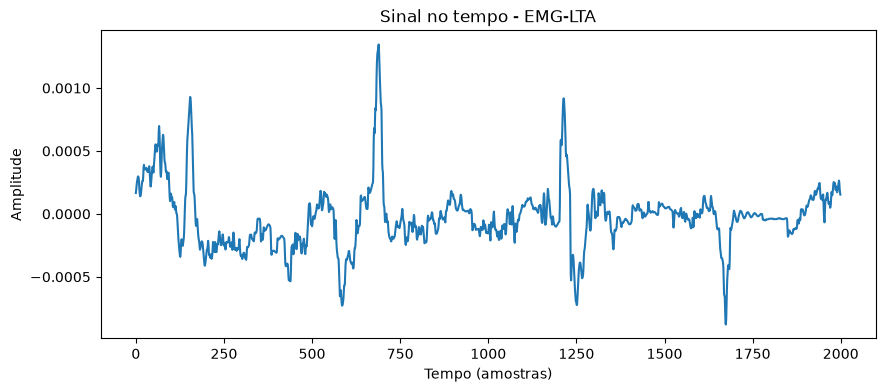

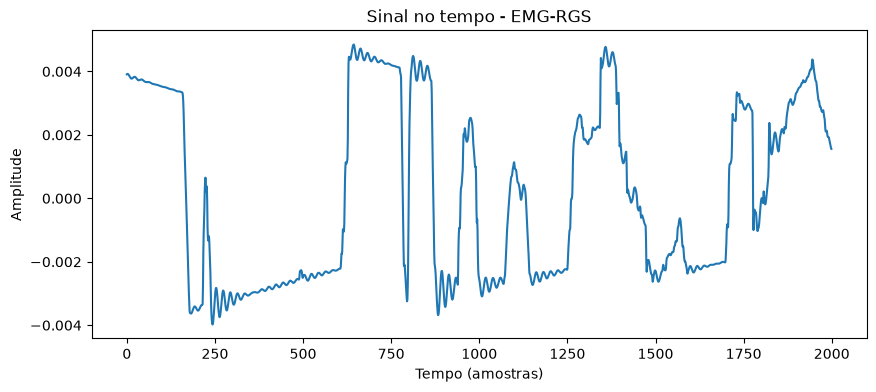

IO: sem dados válidos


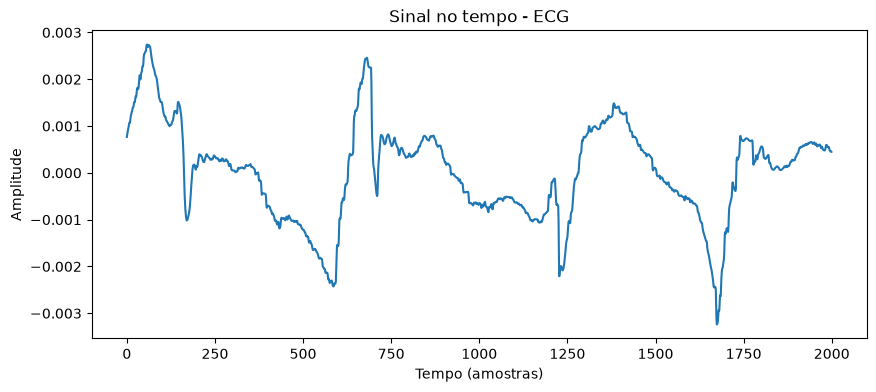

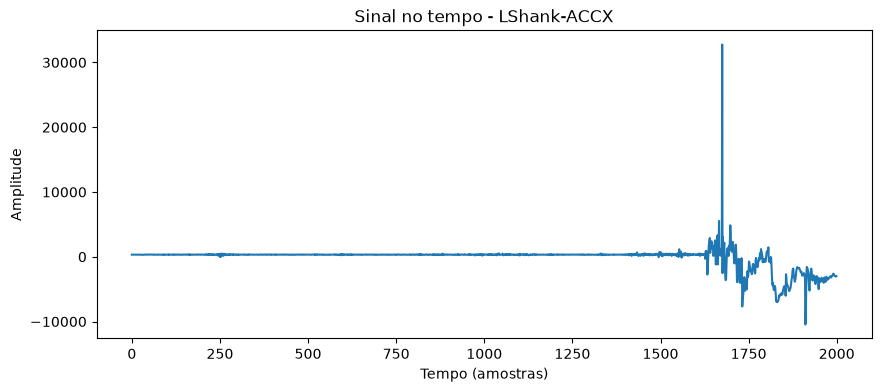

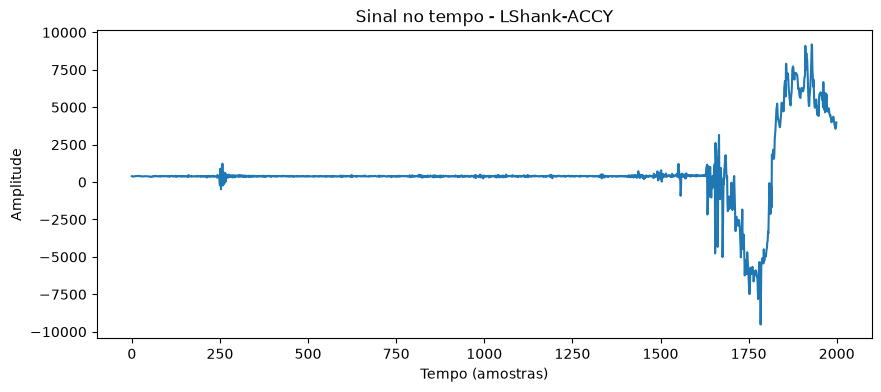

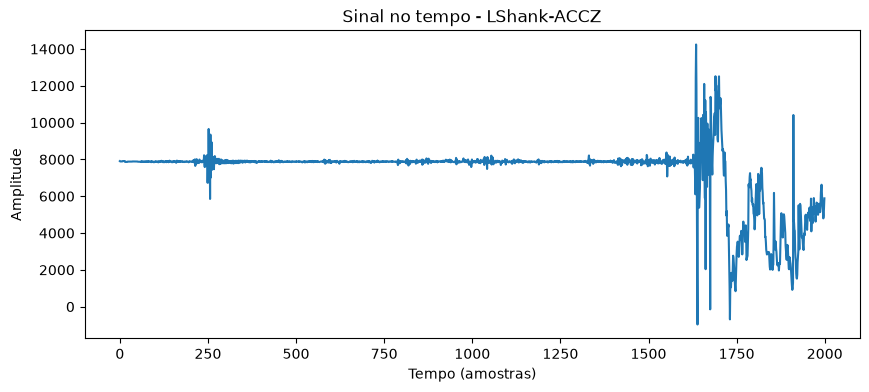

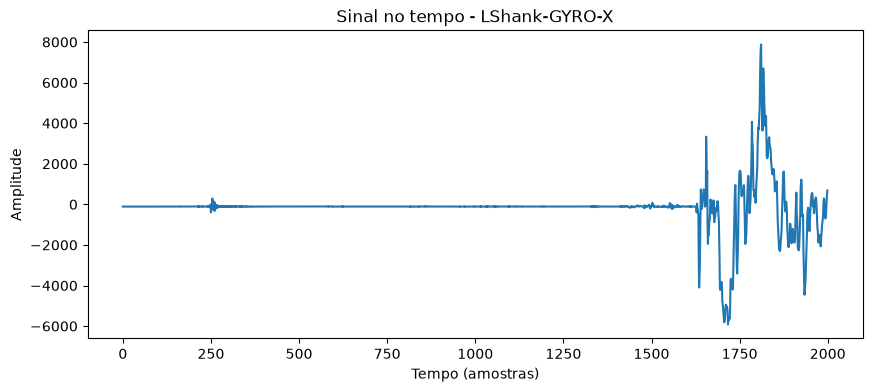

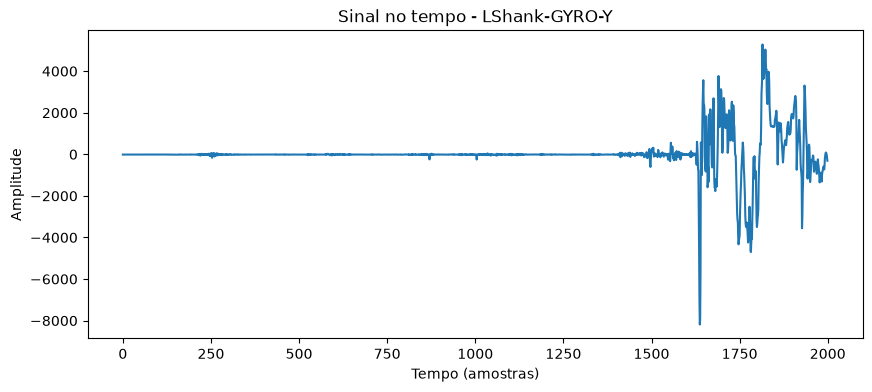

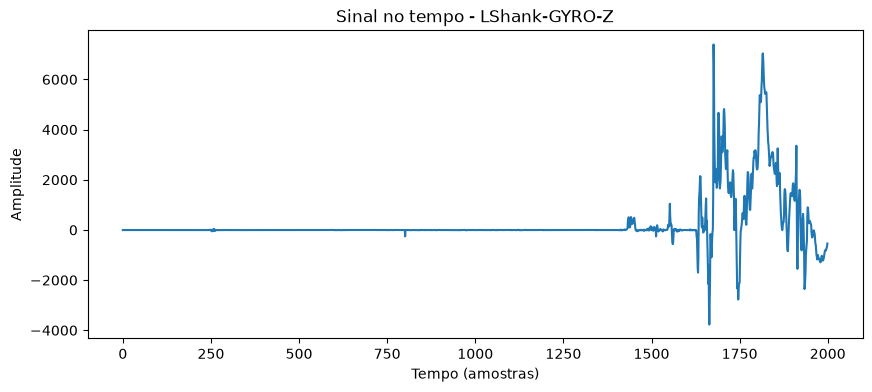

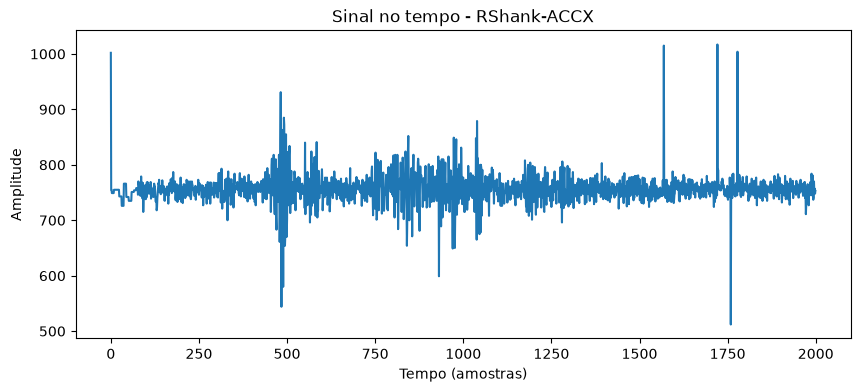

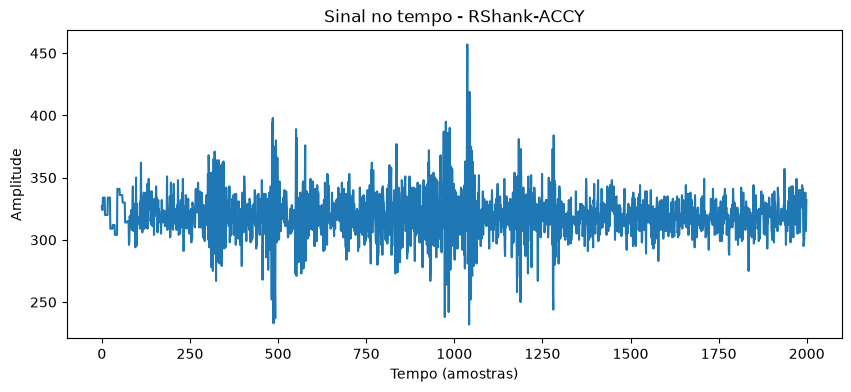

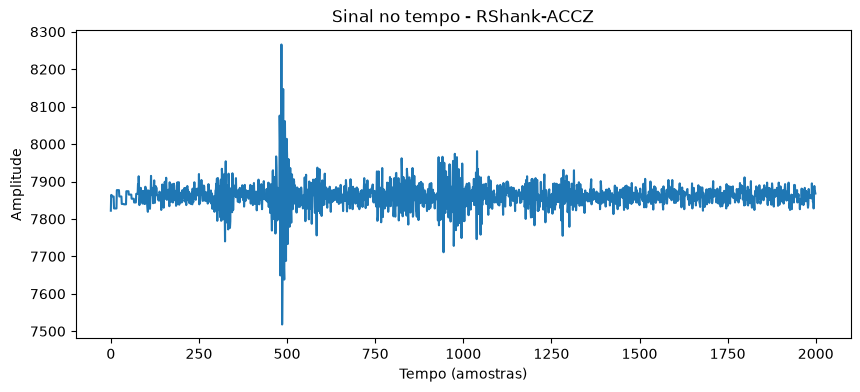

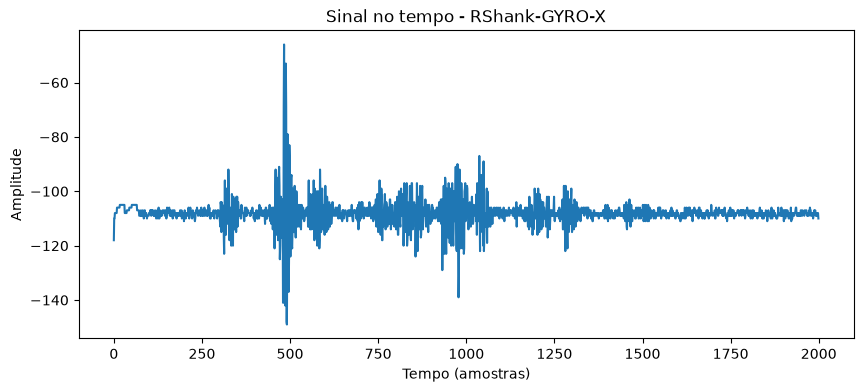

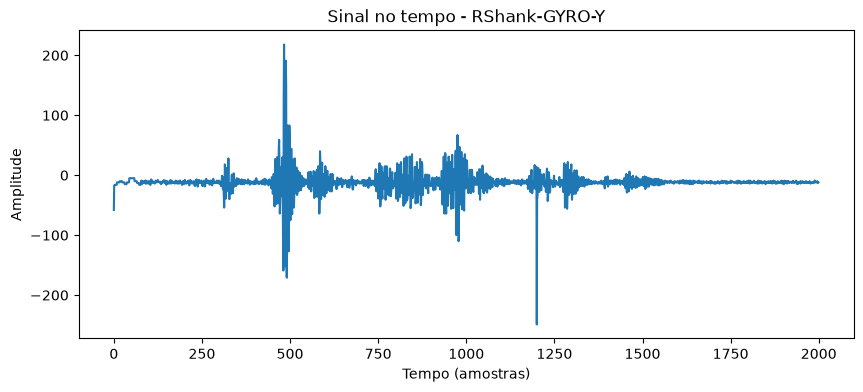

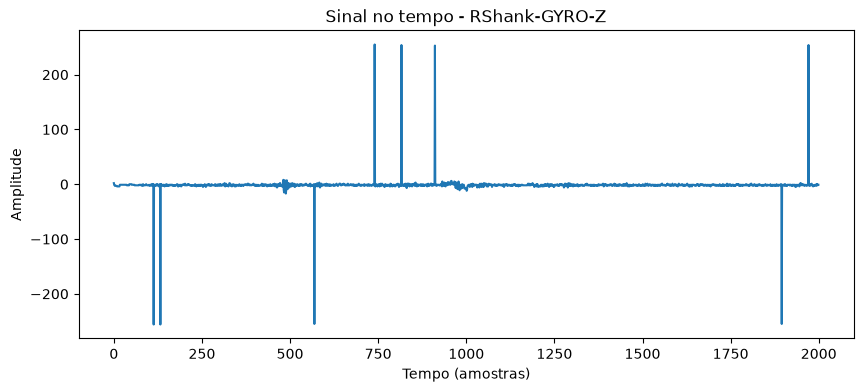

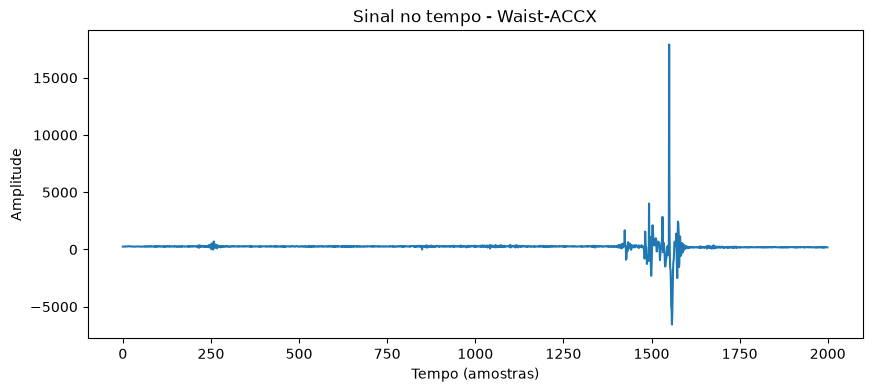

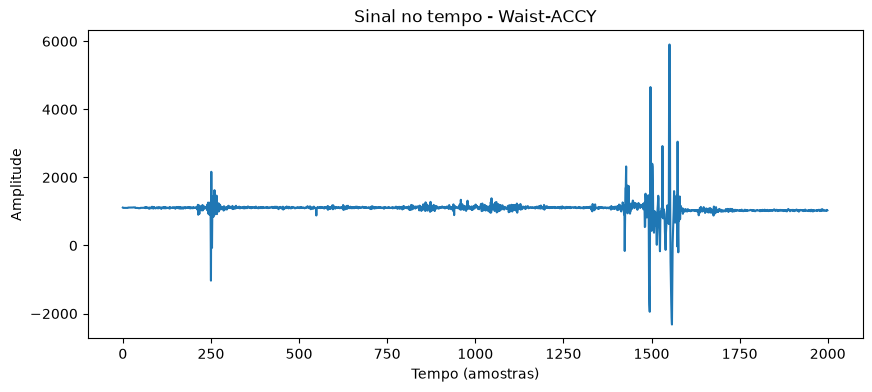

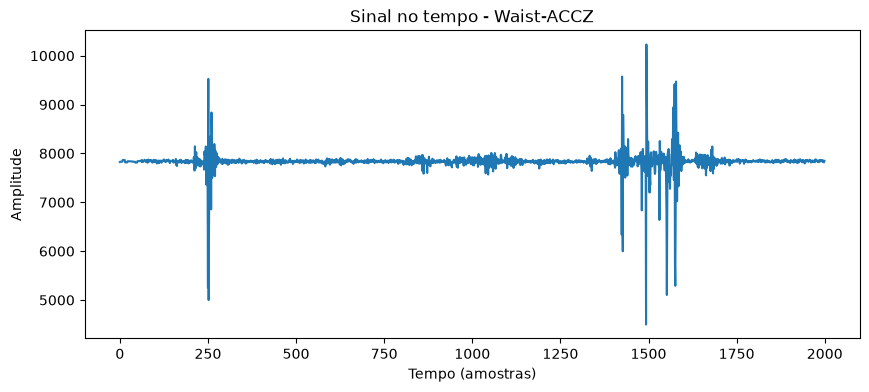

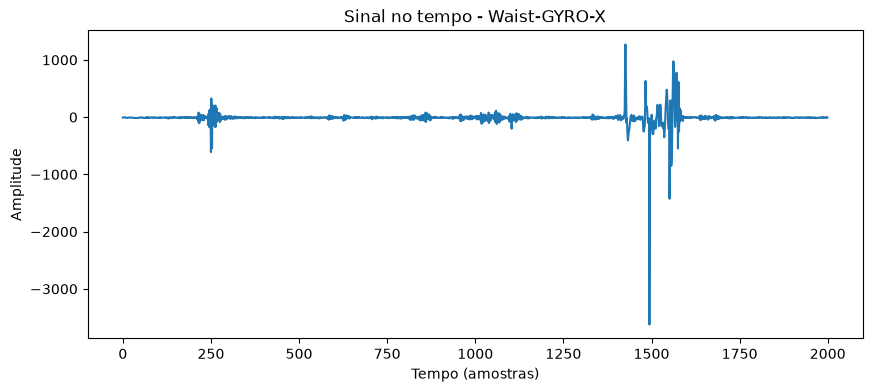

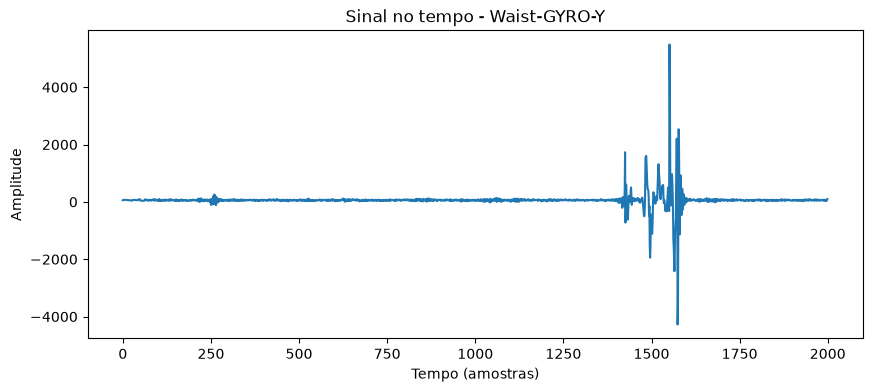

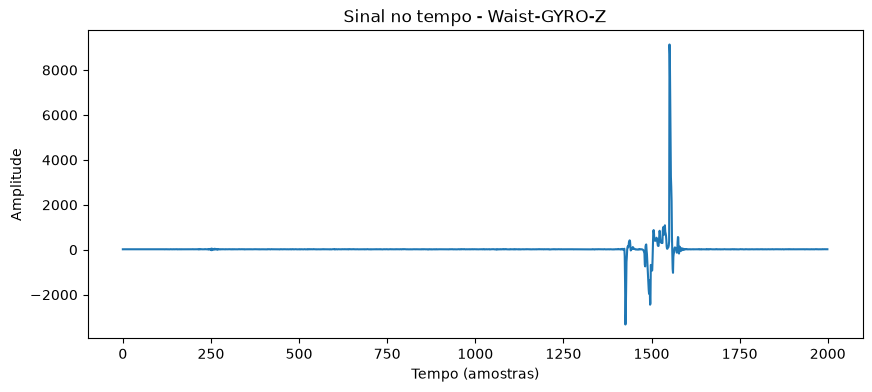

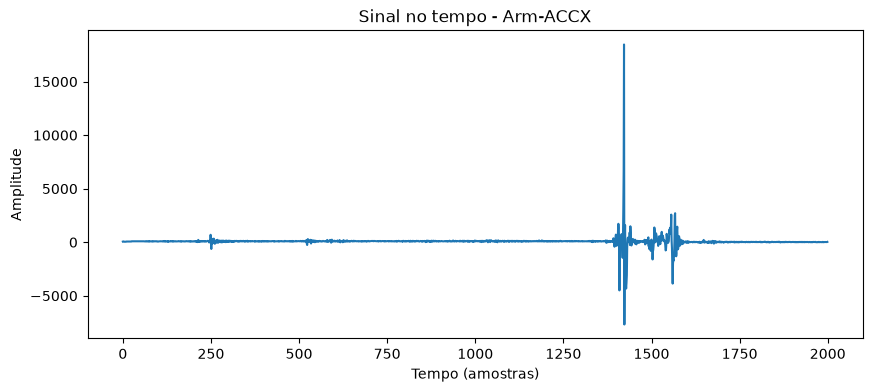

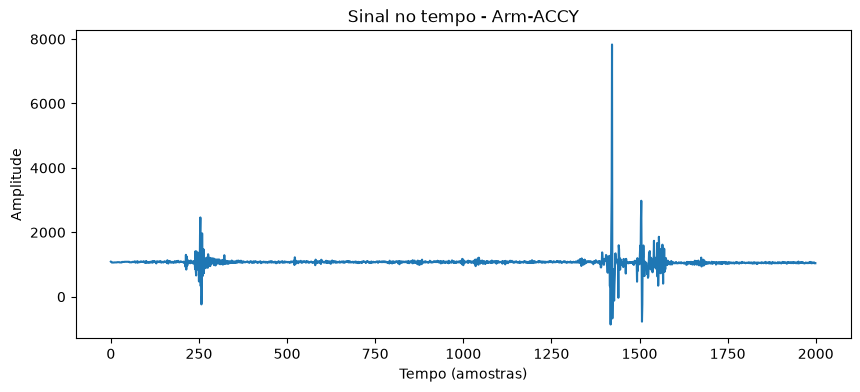

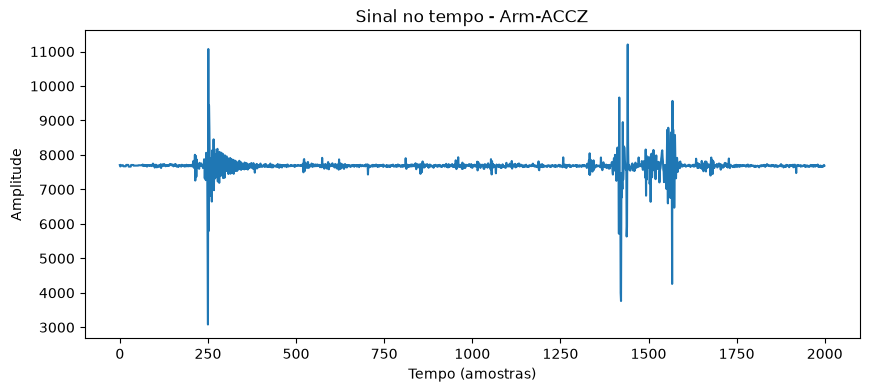

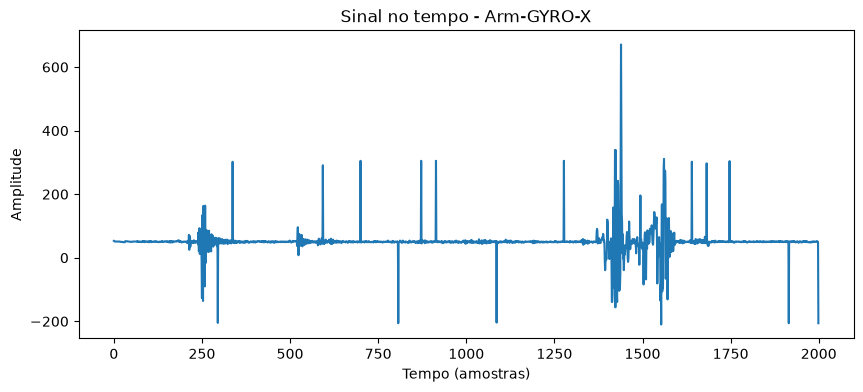

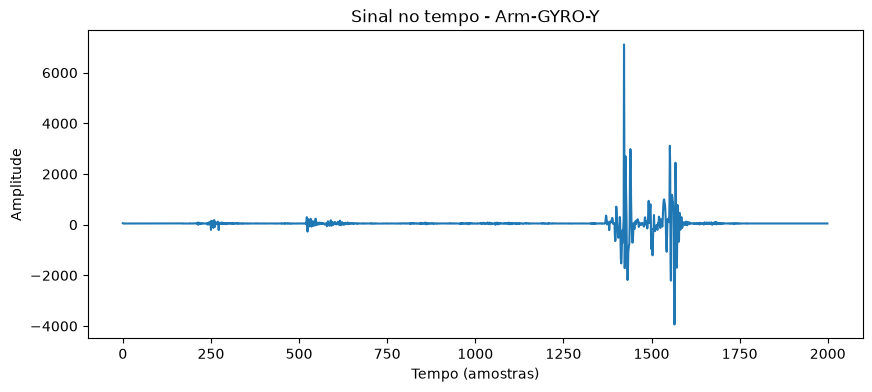

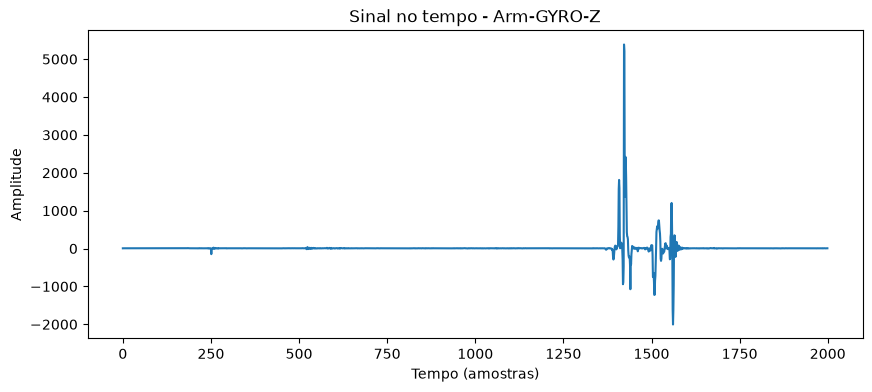

In [7]:
window = 2000

for col in signal_cols:
    if col in df.columns:
        data = clean_series(df[col])

        if data.empty:
            print(f"{col}: sem dados válidos")
            continue

        plt.figure(figsize=(10, 4))
        plt.plot(data.values[:window])
        plt.title(f"Sinal no tempo - {col}")
        plt.xlabel("Tempo (amostras)")
        plt.ylabel("Amplitude")
        plt.show()

Os gráficos de sinal no tempo representam a variação de um canal ao longo das amostras:

Eixo X: tempo (índice das amostras)
Eixo Y: amplitude do sinal

Quando plotamos, por exemplo:

´´´plt.plot(df["Arm-ACCY"].values[:2000])´´´ 

isso não representa um único paciente, na prática é um trecho contínuo do dataset completo, contendo dados concatenados de múltiplos pacientes e sessões.

## 5.1 Matriz de Correlação EEG

In [8]:
import seaborn as sns

corr_cols = [c for c in df.columns if "EEG" in c][:10]  # pega alguns EEG

corr = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=False)
plt.title("Correlação entre canais EEG")
plt.show()

ModuleNotFoundError: No module named 'seaborn'

## 5.2 Matriz de Correlação entre sinais

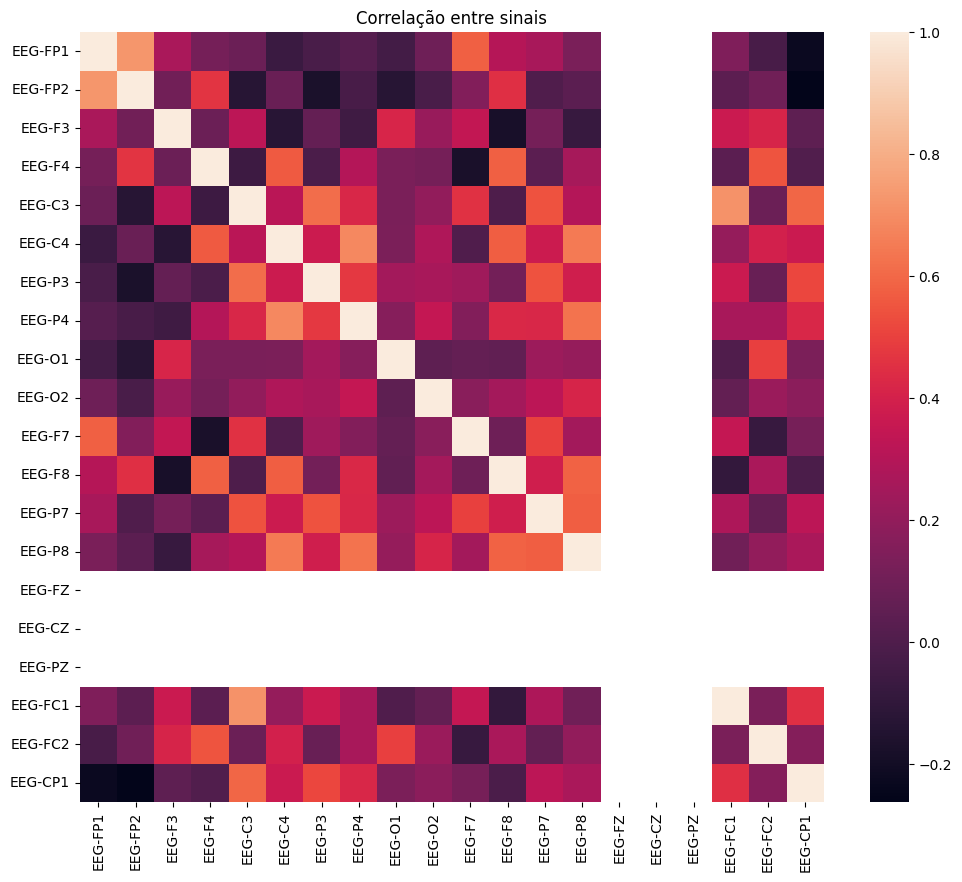

In [ ]:
subset_cols = signal_cols[:20]  # limitar pra não travar

corr = df[subset_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr)
plt.title("Correlação entre sinais")
plt.show()

## 6. Percentual de Valores Nulos

In [ ]:
null_percent = (df[signal_cols].isnull().sum() / len(df)) * 100
null_percent = null_percent.sort_values(ascending=False)

print("\nTop 20 sinais com mais dados faltantes:")
print(null_percent.head(20))


Top 20 sinais com mais dados faltantes:
EEG-FZ           100.000000
EEG-CZ           100.000000
EEG-PZ           100.000000
IO               100.000000
RShank-GYRO-Z     47.493979
RShank-GYRO-Y     47.493979
RShank-ACCX       47.493979
RShank-ACCY       47.493979
RShank-ACCZ       47.493979
RShank-GYRO-X     47.493979
Waist-GYRO-Z      42.674273
Waist-GYRO-Y      42.674273
Waist-GYRO-X      42.674273
Waist-ACCZ        42.674273
Waist-ACCY        42.674273
Waist-ACCX        42.674273
LShank-GYRO-Z     25.775220
LShank-GYRO-X     25.775220
LShank-ACCZ       25.775220
LShank-ACCY       25.775220
dtype: float64


## 7. Energia do Sinal

In [ ]:
def compute_energy(df, signal_cols):
    energy = {}

    for col in signal_cols:
        if col in df.columns:
            data = df[col].replace([np.inf, -np.inf], np.nan).dropna()

            if data.empty:
                continue

            energy[col] = (data**2).mean()

    # ordenar todos
    energy_sorted = dict(sorted(energy.items(), key=lambda x: x[1], reverse=True))

    return energy_sorted


# uso
energy = compute_energy(df, signal_cols)

print("Energia média dos sinais:")
for k, v in energy.items():
    print(f"{k}: {v}")

Energia média dos sinais:
RShank-ACCX: 62702804.0
LShank-ACCX: 62241552.0
Waist-ACCX: 56178032.0
Arm-ACCX: 31475150.0
Arm-ACCY: 21790588.0
Arm-ACCZ: 16751229.0
Waist-ACCZ: 12830159.0
LShank-ACCZ: 12388506.0
RShank-ACCZ: 11549144.0
LShank-ACCY: 7226903.5
RShank-ACCY: 6498226.5
LShank-GYRO-Z: 1926683.0
RShank-GYRO-Z: 1540948.625
Waist-ACCY: 1402826.75
RShank-GYRO-Y: 1220203.75
LShank-GYRO-Y: 1060075.375
RShank-GYRO-X: 766784.9375
LShank-GYRO-X: 762403.5625
Arm-GYRO-X: 474941.65625
Waist-GYRO-X: 276754.09375
Waist-GYRO-Y: 257273.671875
Arm-GYRO-Z: 241886.34375
Arm-GYRO-Y: 233060.46875
Waist-GYRO-Z: 130895.09375
EMG-RGS: 6.669250069535337e-06
EMG-RTA: 6.455245056713466e-06
EMG-LTA: 5.824681466037873e-06
ECG: 2.557457492002868e-06
EEG-O2: 1.4784558022284955e-09
EEG-FP1: 1.3321689307232987e-09
EEG-O1: 1.3287564382125083e-09
EEG-F7: 8.424677067075947e-10
EEG-F8: 7.326794726481012e-10
EEG-FC5: 6.764471760511981e-10
EEG-FP2: 6.391184803611338e-10
EEG-P7: 4.5812201254769036e-10
EEG-P8: 4.1237999

## 8. Estatísticas por Paciente

In [ ]:
grouped = df.groupby(["patient_id", "session"])
stats = grouped.mean(numeric_only=True)

print(stats)

                         EEG-FP1       EEG-FP2        EEG-F3        EEG-F4  \
patient_id session                                                           
001        1        1.331365e-08  2.142076e-08  6.002334e-09  2.710659e-09   
002        1        3.150394e-08  1.522767e-09  9.251480e-09  9.168536e-09   
003        1        6.220049e-08  6.005136e-08  3.814400e-08  1.538825e-08   
004        1        4.605304e-08 -3.102326e-08 -7.113160e-09 -7.304567e-09   
005        1        5.318648e-07  1.678894e-07 -2.413347e-08  8.283343e-08   
006        1        6.386695e-08  2.824702e-08  8.835000e-09  1.362612e-08   
007        1       -1.954995e-07 -3.041408e-07  3.049536e-09 -8.356220e-08   
008        1        8.744104e-08  1.248566e-07 -3.542885e-08  2.684777e-08   
           2       -5.700564e-08 -1.341000e-07 -4.447774e-08 -9.095876e-08   
009        1       -5.266153e-08  1.190300e-08 -2.840449e-08  1.157533e-08   
010        1        8.653494e-10  4.507711e-09  5.286064e-09 -9.

## 9. Estatísticas Globais

In [ ]:
stats = df[signal_cols].describe()

print(stats)

            EEG-FP1       EEG-FP2        EEG-F3        EEG-F4        EEG-C3  \
count  3.872933e+06  3.872933e+06  3.872933e+06  3.872933e+06  3.872933e+06   
mean   2.577336e-08 -9.259656e-09 -2.145931e-09  6.647419e-10  3.650980e-09   
std    3.649888e-05  2.528079e-05  1.479539e-05  1.109508e-05  8.118186e-06   
min   -4.200000e-04 -1.880000e-04 -3.210000e-04 -1.325000e-04 -9.750000e-05   
25%   -1.200000e-05 -1.150000e-05 -5.000000e-06 -5.500000e-06 -4.000000e-06   
50%   -5.000000e-07 -1.000000e-06  0.000000e+00  0.000000e+00  0.000000e+00   
75%    9.500000e-06  9.000000e-06  4.500000e-06  5.500000e-06  4.000000e-06   
max    3.870000e-04  2.560000e-04  4.445000e-04  1.545000e-04  8.800000e-05   

             EEG-C4        EEG-P3        EEG-P4        EEG-O1        EEG-O2  \
count  3.872933e+06  3.872933e+06  3.872933e+06  3.872933e+06  3.872933e+06   
mean   3.634709e-09  7.948755e-09  9.465759e-10  2.578766e-08  2.038996e-08   
std    8.947819e-06  1.183075e-05  1.069370e-05  3.

# Conclusão

Os dados necessitam de um pré-processamento maior para poder termos uma análise estatística melhor.